step 1 import libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


step 2 — Load the CSV
EV Charging Demand Prediction/
│
├── data/
│   └── ev_charging_sessions.csv
│
└── EV_Charging_Demand_Prediction.ipynb

In [46]:
df = pd.read_csv("data/ev_charging_sessions.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


Step 3 — Check dataset shape

In [47]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 72856
Columns: 13


Step 4 — Display first 5 rows

In [48]:
df.head()

,UserID,ChargerID,ChargerCompany,Location,ChargerType,StartDay,StartTime,EndDay,EndTime,StartDatetime,EndDatetime,Duration,Demand
0,0,1,1,hotel,0,2022-09-15,20:54:02,2022-09-15,23:59:13,2022-09-15 20:54,2022-09-15 23:59,185,20.36
1,0,1,1,hotel,0,2022-09-14,20:01:05,2022-09-14,21:31:04,2022-09-14 20:01,2022-09-14 21:31,90,10.19
2,0,1,1,hotel,0,2022-09-14,18:54:30,2022-09-14,19:54:29,2022-09-14 18:54,2022-09-14 19:54,60,6.78
3,0,1,1,hotel,0,2022-09-29,18:32:51,2022-09-30,0:16:42,2022-09-29 18:32,2022-09-30 0:16,344,37.65
4,0,1,1,hotel,0,2022-09-25,19:30:15,2022-09-26,0:30:14,2022-09-25 19:30,2022-09-26 0:30,300,33.81


Step 5 — Check column names

In [49]:
print(df.columns.tolist())

['UserID', 'ChargerID', 'ChargerCompany', 'Location', 'ChargerType', 'StartDay', 'StartTime', 'EndDay', 'EndTime', 'StartDatetime', 'EndDatetime', 'Duration', 'Demand']


Step 6 — Dataset information
This tells us:

number of rows
number of columns
datatype of every column
non-null values
memory usage

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72856 entries, 0 to 72855
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   UserID          72856 non-null  int64  
 1   ChargerID       72856 non-null  int64  
 2   ChargerCompany  72856 non-null  int64  
 3   Location        72856 non-null  str    
 4   ChargerType     72856 non-null  int64  
 5   StartDay        72856 non-null  str    
 6   StartTime       72856 non-null  str    
 7   EndDay          72856 non-null  str    
 8   EndTime         72856 non-null  str    
 9   StartDatetime   72856 non-null  str    
 10  EndDatetime     72856 non-null  str    
 11  Duration        72856 non-null  int64  
 12  Demand          72856 non-null  float64
dtypes: float64(1), int64(5), str(7)
memory usage: 12.5 MB


Step 7 — Check missing values

In [51]:
missing_values = df.isnull().sum()
print(missing_values)


UserID            0
ChargerID         0
ChargerCompany    0
Location          0
ChargerType       0
StartDay          0
StartTime         0
EndDay            0
EndTime           0
StartDatetime     0
EndDatetime       0
Duration          0
Demand            0
dtype: int64


In [52]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing_summary

,Missing Count,Missing Percentage
UserID,0,0.0
ChargerID,0,0.0
ChargerCompany,0,0.0
Location,0,0.0
ChargerType,0,0.0
StartDay,0,0.0
StartTime,0,0.0
EndDay,0,0.0
EndTime,0,0.0
StartDatetime,0,0.0


Step 8 — Check duplicate rows

In [53]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 13


Step 9 — Statistical summary
This will help us understand numerical columns such as:

UserID
ChargerID
ChargerCompany
ChargerType
Duration
Demand

Pay particular attention to:

Duration
Demand

In [54]:
df.describe()

,UserID,ChargerID,ChargerCompany,ChargerType,Duration,Demand
count,72856.000000,72856.000000,72856.000000,72856.00000,72856.000000,72856.000000
mean,338.164667,525.489212,0.627443,0.20524,151.194054,17.444445
std,553.970996,569.544469,0.483489,0.40388,146.430286,13.492728
min,0.000000,1.000000,0.000000,0.00000,-29.000000,0.010000
25%,0.000000,107.000000,0.000000,0.00000,40.000000,7.530000
50%,62.000000,301.000000,1.000000,0.00000,112.000000,14.100000
75%,407.000000,738.000000,1.000000,0.00000,202.000000,23.200000
max,2501.000000,2671.000000,1.000000,1.00000,1573.000000,97.000000


Step 10 — Understand categorical columns


In [55]:
categorical_columns = [
    "ChargerCompany",
    "Location",
    "ChargerType"
]

for col in categorical_columns:
    print("\n", "=" * 50)
    print(col)
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(20))


ChargerCompany
Unique values: 2
ChargerCompany
1    45713
0    27143
Name: count, dtype: int64

Location
Unique values: 14
Location
public area           14082
apartment             14038
resort                 8854
hotel                  8600
company                7558
public institution     7023
public parking lot     3396
market                 3005
restaurant             2222
camping                1630
sightseeing            1203
golf                   1029
accommodation           187
bus garage               29
Name: count, dtype: int64

ChargerType
Unique values: 2
ChargerType
0    57903
1    14953
Name: count, dtype: int64


Step 11 — Number of unique chargers

In [56]:
print("Unique Users:", df["UserID"].nunique())
print("Unique Chargers:", df["ChargerID"].nunique())
print("Unique Companies:", df["ChargerCompany"].nunique())
print("Unique Locations:", df["Location"].nunique())
print("Unique Charger Types:", df["ChargerType"].nunique())

Unique Users: 2337
Unique Chargers: 2119
Unique Companies: 2
Unique Locations: 14
Unique Charger Types: 2


Step 12 — Inspect Demand

In [57]:
print("Demand datatype:", df["Demand"].dtype)

print("\nDemand statistics:")
print(df["Demand"].describe())

Demand datatype: float64

Demand statistics:
count    72856.000000
mean        17.444445
std         13.492728
min          0.010000
25%          7.530000
50%         14.100000
75%         23.200000
max         97.000000
Name: Demand, dtype: float64


In [58]:
print("Minimum Demand:", df["Demand"].min())
print("Maximum Demand:", df["Demand"].max())
print("Mean Demand:", df["Demand"].mean())
print("Median Demand:", df["Demand"].median())

Minimum Demand: 0.01
Maximum Demand: 97.0
Mean Demand: 17.44444548149775
Median Demand: 14.1


Step 13 — Inspect Duration

In [59]:
print("Duration statistics:")
print(df["Duration"].describe())

Duration statistics:
count    72856.000000
mean       151.194054
std        146.430286
min        -29.000000
25%         40.000000
50%        112.000000
75%        202.000000
max       1573.000000
Name: Duration, dtype: float64


In [60]:
print("Minimum Duration:", df["Duration"].min())
print("Maximum Duration:", df["Duration"].max())
print("Mean Duration:", df["Duration"].mean())
print("Median Duration:", df["Duration"].median())

Minimum Duration: -29
Maximum Duration: 1573
Mean Duration: 151.19405402437684
Median Duration: 112.0


Step 14 — Very important: Demand vs Duration

Before deciding whether Duration should be used as a feature, we'll investigate the relationship.

In [61]:
print(
    df[["Duration", "Demand"]].corr()
)

          Duration   Demand
Duration   1.00000  0.65641
Demand     0.65641  1.00000


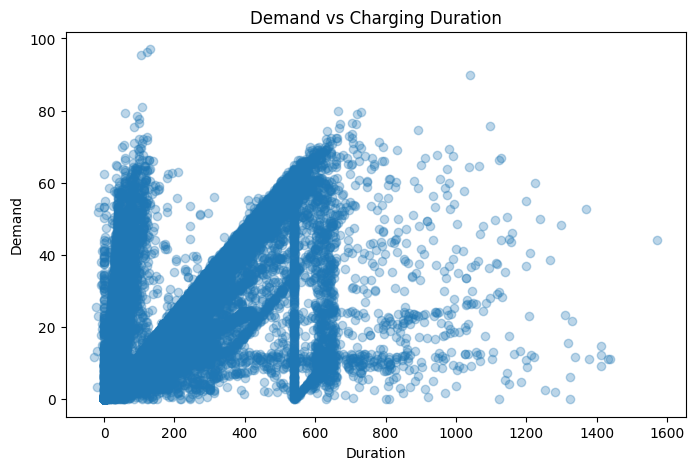

In [62]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Duration"],
    df["Demand"],
    alpha=0.3
)

plt.xlabel("Duration")
plt.ylabel("Demand")
plt.title("Demand vs Charging Duration")

plt.show()

Step 16 — Check date range

For now, convert a temporary copy:

In [63]:
# This tells us the actual time period represented by the dataset.
start_datetime = pd.to_datetime(
    df["StartDatetime"],
    errors="coerce"
)

end_datetime = pd.to_datetime(
    df["EndDatetime"],
    errors="coerce"
)

print("Start date:", start_datetime.min())
print("End date:", start_datetime.max())

Start date: 2021-09-30 17:14:00
End date: 2022-09-30 23:11:00


Step 17 — Check invalid dates

In [64]:
print(
    "Invalid StartDatetime:",
    start_datetime.isna().sum()
)

print(
    "Invalid EndDatetime:",
    end_datetime.isna().sum()
)

Invalid StartDatetime: 0
Invalid EndDatetime: 0


Step 18 — Check Duration consistency

This is another important data-quality check.

Calculate duration ourselves from the timestamps:

In [65]:
calculated_duration = (
    end_datetime - start_datetime
).dt.total_seconds() / 60

comparison = pd.DataFrame({
    "Dataset_Duration": df["Duration"],
    "Calculated_Duration": calculated_duration
})

comparison.head(10)

,Dataset_Duration,Calculated_Duration
0,185,185.0
1,90,90.0
2,60,60.0
3,344,344.0
4,300,300.0
5,70,70.0
6,60,60.0
7,494,494.0
8,60,60.0
9,112,112.0


In [66]:
difference = (
    comparison["Dataset_Duration"]
    - comparison["Calculated_Duration"]
).abs()

print("Maximum duration difference:", difference.max())
print("Mean duration difference:", difference.mean())

Maximum duration difference: 4320.0
Mean duration difference: 4.7932771494454816


So we want to verify whether Duration is actually:

charging duration in minutes

rather than blindly assuming it.

Step 19 — Check whether Demand is always positive

In [67]:
print("Demand <= 0:", (df["Demand"] <= 0).sum())

Demand <= 0: 0


In [68]:
print("Duration <= 0:", (df["Duration"] <= 0).sum())

Duration <= 0: 735


Step 20 — Check the first chronological records

In [69]:
df_temp = df.copy()

df_temp["StartDatetime"] = pd.to_datetime(
    df_temp["StartDatetime"],
    errors="coerce"
)

df_temp = df_temp.sort_values("StartDatetime")

df_temp[
    [
        "StartDatetime",
        "ChargerID",
        "Location",
        "ChargerType",
        "Duration",
        "Demand"
    ]
].head(20)

,StartDatetime,ChargerID,Location,ChargerType,Duration,Demand
35854,2021-09-30 17:14:00,291,public institution,0,487,27.68
26889,2021-09-30 18:22:00,191,resort,0,478,55.13
38021,2021-09-30 18:57:00,320,camping,0,347,38.45
44790,2021-09-30 19:52:00,433,camping,0,269,30.17
31676,2021-09-30 20:48:00,250,public area,0,406,47.00
31429,2021-09-30 21:05:00,248,public institution,0,182,20.89
37767,2021-09-30 21:08:00,312,public area,0,458,52.04
32336,2021-09-30 21:16:00,260,public institution,0,208,22.30
28472,2021-09-30 21:39:00,211,company,0,194,22.31
12590,2021-09-30 22:13:00,64,apartment,0,523,59.30


PHASE 2 — Data Cleaning + EDA

This is where you are now.

Step 21 — Missing-value investigation

Decision

Depending on the result:

No missing values → continue
Missing categorical values → decide whether to remove/fill
Missing numerical values → investigate before filling
Missing target Demand → generally cannot train those rows

Do not delete anything blindly.

In [70]:
# Check rows containing missing values

missing_rows = df[df.isnull().any(axis=1)]

print("Number of rows with missing values:", len(missing_rows))

missing_rows.head(10)

Number of rows with missing values: 0


,UserID,ChargerID,ChargerCompany,Location,ChargerType,StartDay,StartTime,EndDay,EndTime,StartDatetime,EndDatetime,Duration,Demand


Step 22 — Duplicate investigation

In [71]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 13


In [72]:
df[df.duplicated(keep=False)].head(10)

,UserID,ChargerID,ChargerCompany,Location,ChargerType,StartDay,StartTime,EndDay,EndTime,StartDatetime,EndDatetime,Duration,Demand
28856,329,214,1,public area,0,2022-02-12,7:22:40,2022-02-12,15:44:27,2022-02-12 7:22,2022-02-12 15:44,502,54.34
28857,329,214,1,public area,0,2022-02-12,7:22:40,2022-02-12,15:44:27,2022-02-12 7:22,2022-02-12 15:44,502,54.34
28858,329,214,1,public area,0,2022-02-15,19:29:42,2022-02-15,23:03:11,2022-02-15 19:29,2022-02-15 23:03,213,23.68
28859,329,214,1,public area,0,2022-02-15,19:29:42,2022-02-15,23:03:11,2022-02-15 19:29,2022-02-15 23:03,213,23.68
28861,329,214,1,public area,0,2022-02-17,18:53:55,2022-02-18,3:38:13,2022-02-17 18:53,2022-02-18 3:38,524,58.06
28862,329,214,1,public area,0,2022-02-17,18:53:55,2022-02-18,3:38:13,2022-02-17 18:53,2022-02-18 3:38,524,58.06
40669,461,371,1,apartment,0,2022-02-22,16:17:01,2022-02-22,21:38:44,2022-02-22 16:17,2022-02-22 21:38,322,37.74
40670,461,371,1,apartment,0,2022-02-22,16:17:01,2022-02-22,21:38:44,2022-02-22 16:17,2022-02-22 21:38,322,37.74
51498,276,640,0,company,1,2022-02-26,9:23:02,2022-02-26,10:03:07,2022-02-26 9:23,2022-02-26 10:03,40,15.04
51499,276,640,0,company,1,2022-02-26,9:23:02,2022-02-26,10:03:07,2022-02-26 9:23,2022-02-26 10:03,40,15.04


Step 23 — Datetime validation

In [73]:
df["StartDatetime"] = pd.to_datetime(df["StartDatetime"], errors="coerce")
df["EndDatetime"] = pd.to_datetime(df["EndDatetime"], errors="coerce")

In [74]:
print("Invalid StartDatetime:", df["StartDatetime"].isna().sum())
print("Invalid EndDatetime:", df["EndDatetime"].isna().sum())

Invalid StartDatetime: 0
Invalid EndDatetime: 0


In [75]:
invalid_time = df[df["EndDatetime"] < df["StartDatetime"]]

print("End before Start:", len(invalid_time))

End before Start: 17


This is important because charging sessions cannot normally finish before they start.

Step 24 — Validate Duration

Create calculated duration from timestamps:

In [76]:
df["CalculatedDuration"] = (
    df["EndDatetime"] - df["StartDatetime"]
).dt.total_seconds() / 60

In [77]:
df[["Duration", "CalculatedDuration"]].head()

,Duration,CalculatedDuration
0,185,185.0
1,90,90.0
2,60,60.0
3,344,344.0
4,300,300.0


In [78]:
difference = (
    df["Duration"] - df["CalculatedDuration"]
).abs()

print("Maximum difference:", difference.max())
print("Mean difference:", difference.mean())

Maximum difference: 4320.0
Mean difference: 4.7932771494454816


Step 25 — Demand validation

Check:

In [79]:
print("Minimum Demand:", df["Demand"].min())
print("Maximum Demand:", df["Demand"].max())
print("Zero Demand:", (df["Demand"] == 0).sum())
print("Negative Demand:", (df["Demand"] < 0).sum())

Minimum Demand: 0.01
Maximum Demand: 97.0
Zero Demand: 0
Negative Demand: 0


In [80]:
df[df["Demand"] <= 0].head(20)

,UserID,ChargerID,ChargerCompany,Location,ChargerType,StartDay,StartTime,EndDay,EndTime,StartDatetime,EndDatetime,Duration,Demand,CalculatedDuration


we will decide what to do based on the actual output.

Also remember:

We will call the target Demand, not kWh, unless the dataset documentation confirms the unit.

Step 26 — Outlier investigation

We will inspect Demand:

In [81]:
df["Demand"].describe()

count    72856.000000
mean        17.444445
std         13.492728
min          0.010000
25%          7.530000
50%         14.100000
75%         23.200000
max         97.000000
Name: Demand, dtype: float64

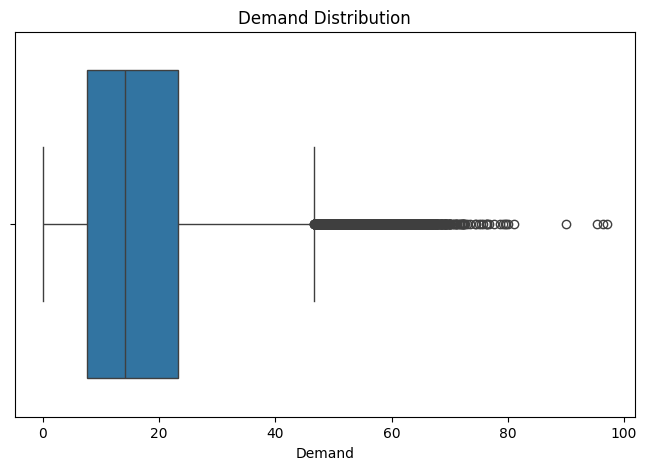

In [82]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Demand"])
plt.title("Demand Distribution")
plt.show()

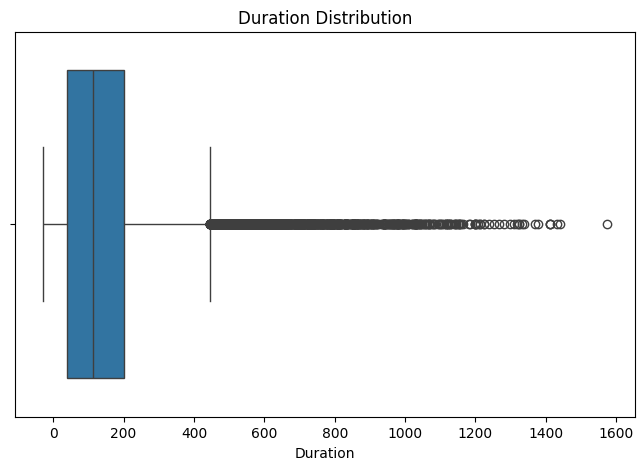

In [83]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Duration"])
plt.title("Duration Distribution")
plt.show()

Important: outlier ≠ automatically bad data.

We investigate before removing anything.

Step 27 — Categorical consistency

Check:

In [84]:
for col in ["ChargerCompany", "Location", "ChargerType"]:
    print("\n", col)
    print(df[col].value_counts())


 ChargerCompany
ChargerCompany
1    45713
0    27143
Name: count, dtype: int64

 Location
Location
public area           14082
apartment             14038
resort                 8854
hotel                  8600
company                7558
public institution     7023
public parking lot     3396
market                 3005
restaurant             2222
camping                1630
sightseeing            1203
golf                   1029
accommodation           187
bus garage               29
Name: count, dtype: int64

 ChargerType
ChargerType
0    57903
1    14953
Name: count, dtype: int64


Step 28 — Create cleaned dataframe

Only after investigating Steps 21–27, we create the cleaned dataset.

Something conceptually like:

In [85]:
df_clean = df.copy()

Then perform only the cleaning decisions that the actual data justifies.

PHASE 2B — EDA

Once cleaning is finished, we analyze the dataset.

Step 29 — Demand distribution

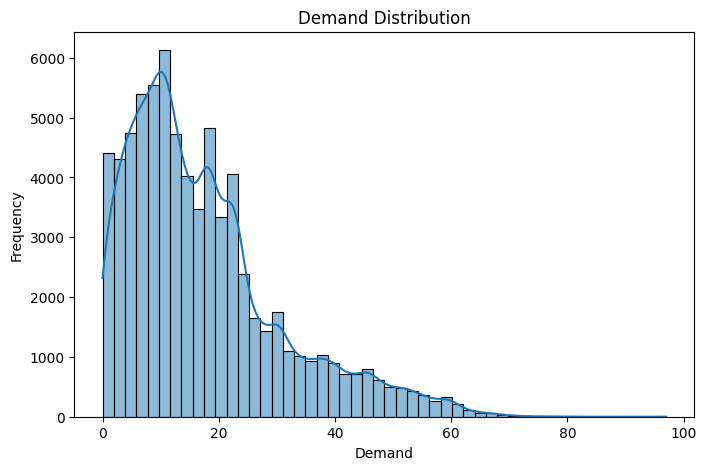

In [87]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Demand"], bins=50, kde=True)

plt.title("Demand Distribution")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.show()

In [88]:
df_clean["Demand"].describe()

count    72856.000000
mean        17.444445
std         13.492728
min          0.010000
25%          7.530000
50%         14.100000
75%         23.200000
max         97.000000
Name: Demand, dtype: float64

Step 30 — Duration distribution

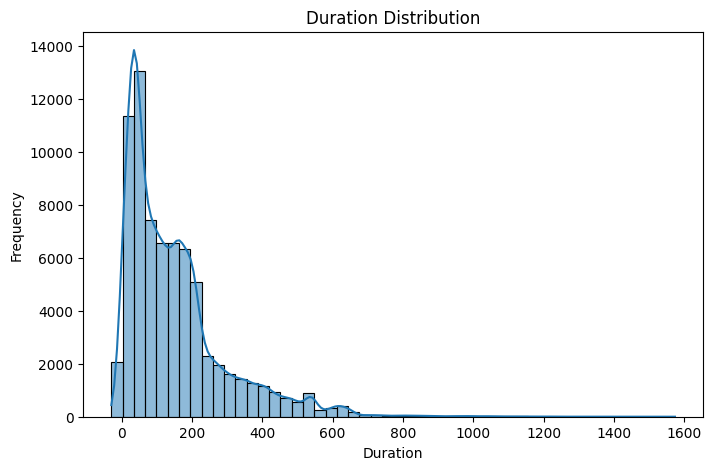

In [89]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Duration"], bins=50, kde=True)

plt.title("Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show()

Step 31 — Demand vs Duration

This is an important analysis.

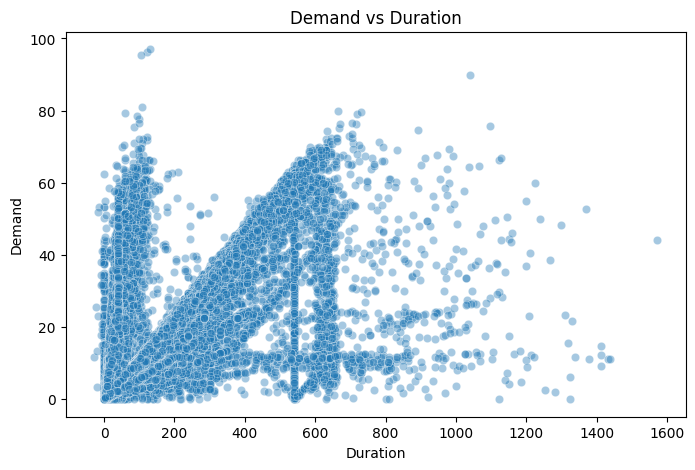

In [90]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_clean,
    x="Duration",
    y="Demand",
    alpha=0.4
)

plt.title("Demand vs Duration")
plt.xlabel("Duration")
plt.ylabel("Demand")
plt.show()

In [91]:
df_clean[["Duration", "Demand"]].corr()

,Duration,Demand
Duration,1.00000,0.65641
Demand,0.65641,1.00000


We already suspect a strong relationship, so this will help us understand whether Duration can create leakage.

Step 32 — Create temporal features for EDA

We'll create:

In [92]:
df_clean["Hour"] = df_clean["StartDatetime"].dt.hour
df_clean["DayOfWeek"] = df_clean["StartDatetime"].dt.dayofweek
df_clean["Month"] = df_clean["StartDatetime"].dt.month
df_clean["Year"] = df_clean["StartDatetime"].dt.year
df_clean["IsWeekend"] = df_clean["DayOfWeek"] >= 5

Step 33 — Demand by hour

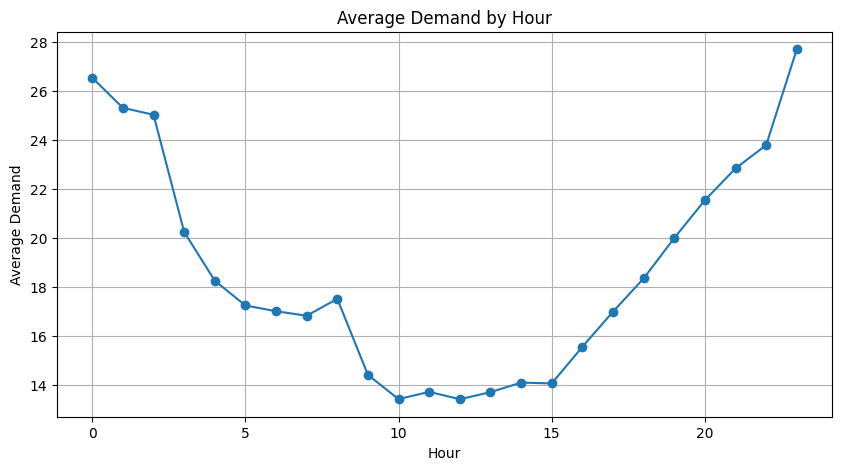

In [93]:
hourly_demand = df_clean.groupby("Hour")["Demand"].mean()

plt.figure(figsize=(10,5))

hourly_demand.plot(marker="o")

plt.title("Average Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Demand")
plt.grid()
plt.show()

Step 34 — Session frequency by hour

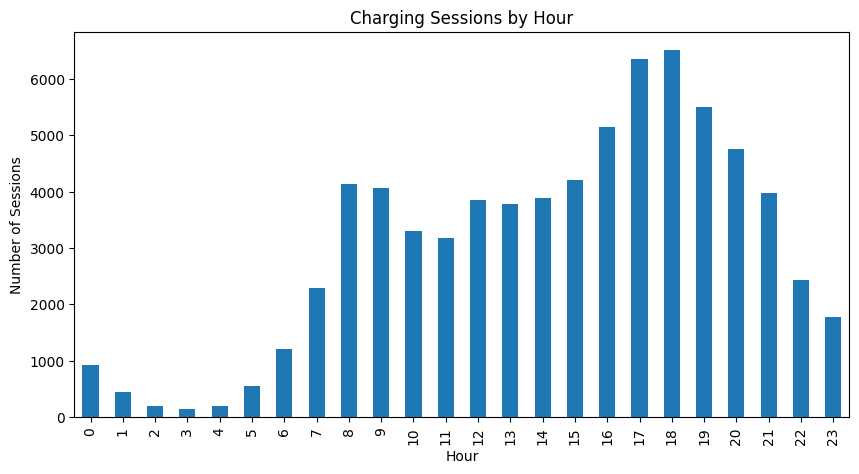

In [94]:
hourly_sessions = df_clean["Hour"].value_counts().sort_index()

plt.figure(figsize=(10,5))

hourly_sessions.plot(kind="bar")

plt.title("Charging Sessions by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Sessions")
plt.show()

This is different from average Demand.

That's important for the utilization-analysis component.

Step 35 — Demand by weekday

In [95]:
weekday_demand = df_clean.groupby("DayOfWeek")["Demand"].mean()

weekday_demand

DayOfWeek
0    17.352587
1    17.107351
2    17.528346
3    17.633585
4    17.308190
5    17.422613
6    17.806092
Name: Demand, dtype: float64

Step 36 — Weekend vs weekday

In [96]:
df_clean.groupby("IsWeekend")["Demand"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
IsWeekend,,,
False,53918,17.388168,14.06
True,18938,17.604673,14.26


Step 37 — Demand by month

In [97]:
monthly_demand = df_clean.groupby("Month")["Demand"].mean()

monthly_demand

Month
1     17.391593
2     17.696241
3     17.485474
4     17.384997
5     17.239948
6     17.471306
7     17.708754
8     17.696557
9     17.792391
10    16.522514
11    16.758129
12    17.529455
Name: Demand, dtype: float64

Step 38 — Location analysis

Session frequency:

In [99]:
location_sessions = df_clean["Location"].value_counts()

location_sessions

Location
public area           14082
apartment             14038
resort                 8854
hotel                  8600
company                7558
public institution     7023
public parking lot     3396
market                 3005
restaurant             2222
camping                1630
sightseeing            1203
golf                   1029
accommodation           187
bus garage               29
Name: count, dtype: int64

Average Demand:

In [100]:
location_demand = (
    df_clean.groupby("Location")["Demand"]
    .agg(["count", "mean", "sum"])
    .sort_values("count", ascending=False)
)

location_demand

,count,mean,sum
Location,,,
public area,14082,17.906683,252161.91
apartment,14038,18.746507,263163.46
resort,8854,17.280838,153004.54
hotel,8600,14.704900,126462.14
company,7558,16.247879,122801.47
public institution,7023,17.399318,122195.41
public parking lot,3396,17.186767,58366.26
market,3005,16.567338,49784.85
restaurant,2222,17.813123,39580.76


Step 39 — Charger analysis

In [101]:
charger_analysis = (
    df_clean.groupby("ChargerID")["Demand"]
    .agg(["count", "mean", "sum"])
    .sort_values("count", ascending=False)
)

charger_analysis.head(10)
# this helps us identify frequently used chargers and demand patterns.

,count,mean,sum
ChargerID,,,
573,674,12.963620,8737.48
25,658,14.414119,9484.49
163,648,16.984367,11005.87
95,576,15.451632,8900.14
273,576,16.378090,9433.78
29,557,14.605296,8135.15
3,549,14.027596,7701.15
30,530,16.166925,8568.47
33,513,15.914834,8164.31


Step 40 — Charger type analysis

In [102]:
charger_type_analysis = (
    df_clean.groupby("ChargerType")["Demand"]
    .agg(["count", "mean", "median", "sum"])
)

charger_type_analysis

,count,mean,median,sum
ChargerType,,,,
0,57903,17.054121,13.10,987484.78
1,14953,18.955911,17.16,283447.74


PHASE 3 — Feature Engineering

This is one of the most important parts of your project.

Your final model should not simply be:
Random Forest → Demand

We want:

Raw charging data
       ↓
Temporal features
       ↓
Historical features
       ↓
Leakage-safe features
       ↓
ML model
       ↓
Demand prediction

The project specifically emphasizes temporal feature engineering and leakage prevention.

Step 41 — Decide the prediction scenario

We need to formally choose:

Scenario A
Charger
Location
Time
Duration
        ↓
Demand

OR

Scenario B
Charger
Location
Start time
Calendar features
Historical demand
        ↓
Demand

 we'll carefully evaluate Scenario B, because it avoids using completed-session Duration as future information.

We won't make this decision based simply on whichever gives the highest R².

Step 42 — Temporal features

Create:

In [103]:
# Step 42 - Create additional temporal features

df_clean["DayOfMonth"] = df_clean["StartDatetime"].dt.day
df_clean["WeekOfYear"] = df_clean["StartDatetime"].dt.isocalendar().week.astype(int)

df_clean[[
    "StartDatetime",
    "Hour",
    "DayOfWeek",
    "DayOfMonth",
    "WeekOfYear",
    "Month",
    "Year",
    "IsWeekend"
]].head()

,StartDatetime,Hour,DayOfWeek,DayOfMonth,WeekOfYear,Month,Year,IsWeekend
0,2022-09-15 20:54:00,20,3,15,37,9,2022,False
1,2022-09-14 20:01:00,20,2,14,37,9,2022,False
2,2022-09-14 18:54:00,18,2,14,37,9,2022,False
3,2022-09-29 18:32:00,18,3,29,39,9,2022,False
4,2022-09-25 19:30:00,19,6,25,38,9,2022,True


What each new feature means

DayOfMonth

1 → first day of month
15 → fifteenth day
30 → thirtieth day

WeekOfYear

1 → first week of the year
...
52/53 → later weeks

STEP 43 — Sort chronologically
Why?

Historical features only make sense if the dataframe is ordered from past → future.

In [104]:
# Step 43 - Sort data chronologically

df_clean = df_clean.sort_values("StartDatetime").reset_index(drop=True)

df_clean[[
    "StartDatetime",
    "ChargerID",
    "Location",
    "Demand"
]].head(10)

,StartDatetime,ChargerID,Location,Demand
0,2021-09-30 17:14:00,291,public institution,27.68
1,2021-09-30 18:22:00,191,resort,55.13
2,2021-09-30 18:57:00,320,camping,38.45
3,2021-09-30 19:52:00,433,camping,30.17
4,2021-09-30 20:48:00,250,public area,47.00
5,2021-09-30 21:05:00,248,public institution,20.89
6,2021-09-30 21:08:00,312,public area,52.04
7,2021-09-30 21:16:00,260,public institution,22.30
8,2021-09-30 21:39:00,211,company,22.31
9,2021-09-30 22:13:00,64,apartment,59.30


You should see the earliest sessions first.

STEP 44 — Previous charger demand
Why?

For a new session at a charger, the previous demand from that charger can be useful historical information

In [105]:
# Step 44 - Previous demand for the same charger

df_clean["PreviousChargerDemand"] = (
    df_clean.groupby("ChargerID")["Demand"].shift(1)
)

df_clean[[
    "StartDatetime",
    "ChargerID",
    "Demand",
    "PreviousChargerDemand"
]].head(15)

# Important:

# shift(1) means:

# Current row
#     ↓
# uses previous row's Demand

# It does not use the current Demand.

,StartDatetime,ChargerID,Demand,PreviousChargerDemand
0,2021-09-30 17:14:00,291,27.68,NaN
1,2021-09-30 18:22:00,191,55.13,NaN
2,2021-09-30 18:57:00,320,38.45,NaN
3,2021-09-30 19:52:00,433,30.17,NaN
4,2021-09-30 20:48:00,250,47.00,NaN
5,2021-09-30 21:05:00,248,20.89,NaN
6,2021-09-30 21:08:00,312,52.04,NaN
7,2021-09-30 21:16:00,260,22.30,NaN
8,2021-09-30 21:39:00,211,22.31,NaN
9,2021-09-30 22:13:00,64,59.30,NaN


In [106]:
STEP 45 — Previous location demand

SyntaxError: invalid character '—' (U+2014) (1942541836.py, line 1)

In [107]:
# Step 45 - Previous demand for the same location

df_clean["PreviousLocationDemand"] = (
    df_clean.groupby("Location")["Demand"].shift(1)
)

df_clean[[
    "StartDatetime",
    "Location",
    "Demand",
    "PreviousLocationDemand"
]].head(15)

,StartDatetime,Location,Demand,PreviousLocationDemand
0,2021-09-30 17:14:00,public institution,27.68,NaN
1,2021-09-30 18:22:00,resort,55.13,NaN
2,2021-09-30 18:57:00,camping,38.45,NaN
3,2021-09-30 19:52:00,camping,30.17,38.45
4,2021-09-30 20:48:00,public area,47.00,NaN
5,2021-09-30 21:05:00,public institution,20.89,27.68
6,2021-09-30 21:08:00,public area,52.04,47.00
7,2021-09-30 21:16:00,public institution,22.30,20.89
8,2021-09-30 21:39:00,company,22.31,NaN
9,2021-09-30 22:13:00,apartment,59.30,NaN


This gives the model information about recent demand at that location.

STEP 46 — Historical charger average

Now we calculate the average Demand for a charger using only previous observations.

In [108]:
# Step 46 - Historical average demand for each charger

df_clean["HistoricalChargerMean"] = (
    df_clean.groupby("ChargerID")["Demand"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

df_clean[[
    "StartDatetime",
    "ChargerID",
    "Demand",
    "HistoricalChargerMean"
]].head(20)

,StartDatetime,ChargerID,Demand,HistoricalChargerMean
0,2021-09-30 17:14:00,291,27.68,NaN
1,2021-09-30 18:22:00,191,55.13,NaN
2,2021-09-30 18:57:00,320,38.45,NaN
3,2021-09-30 19:52:00,433,30.17,NaN
4,2021-09-30 20:48:00,250,47.00,NaN
5,2021-09-30 21:05:00,248,20.89,NaN
6,2021-09-30 21:08:00,312,52.04,NaN
7,2021-09-30 21:16:00,260,22.30,NaN
8,2021-09-30 21:39:00,211,22.31,NaN
9,2021-09-30 22:13:00,64,59.30,NaN


Very important

This:

x.shift(1).expanding().mean()

means:

Past observations only
        ↓
Historical average
        ↓
Current prediction

So the current Demand is not included.

STEP 47 — Historical location average

In [109]:
# Step 47 - Historical average demand for each location

df_clean["HistoricalLocationMean"] = (
    df_clean.groupby("Location")["Demand"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

df_clean[[
    "StartDatetime",
    "Location",
    "Demand",
    "HistoricalLocationMean"
]].head(20)

,StartDatetime,Location,Demand,HistoricalLocationMean
0,2021-09-30 17:14:00,public institution,27.68,NaN
1,2021-09-30 18:22:00,resort,55.13,NaN
2,2021-09-30 18:57:00,camping,38.45,NaN
3,2021-09-30 19:52:00,camping,30.17,38.450000
4,2021-09-30 20:48:00,public area,47.00,NaN
5,2021-09-30 21:05:00,public institution,20.89,27.680000
6,2021-09-30 21:08:00,public area,52.04,47.000000
7,2021-09-30 21:16:00,public institution,22.30,24.285000
8,2021-09-30 21:39:00,company,22.31,NaN
9,2021-09-30 22:13:00,apartment,59.30,NaN


Again, only previous observations are used.

STEP 48 — Charger + Hour historical average

This is an especially useful feature.

For example:

What has the average Demand historically been for Charger 5 at 8 PM?

In [110]:
# Step 48 - Historical average for Charger + Hour

df_clean["ChargerHourHistoricalMean"] = (
    df_clean.groupby(["ChargerID", "Hour"])["Demand"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

df_clean[[
    "StartDatetime",
    "ChargerID",
    "Hour",
    "Demand",
    "ChargerHourHistoricalMean"
]].head(20)

,StartDatetime,ChargerID,Hour,Demand,ChargerHourHistoricalMean
0,2021-09-30 17:14:00,291,17,27.68,NaN
1,2021-09-30 18:22:00,191,18,55.13,NaN
2,2021-09-30 18:57:00,320,18,38.45,NaN
3,2021-09-30 19:52:00,433,19,30.17,NaN
4,2021-09-30 20:48:00,250,20,47.00,NaN
5,2021-09-30 21:05:00,248,21,20.89,NaN
6,2021-09-30 21:08:00,312,21,52.04,NaN
7,2021-09-30 21:16:00,260,21,22.30,NaN
8,2021-09-30 21:39:00,211,21,22.31,NaN
9,2021-09-30 22:13:00,64,22,59.30,NaN


STEP 49 — Check historical-feature missing values

The first observation of a charger/location/hour combination may have no historical information.

That is normal.

In [111]:
# Step 49 - Check missing values in historical features

historical_features = [
    "PreviousChargerDemand",
    "PreviousLocationDemand",
    "HistoricalChargerMean",
    "HistoricalLocationMean",
    "ChargerHourHistoricalMean"
]

df_clean[historical_features].isnull().sum()

PreviousChargerDemand         2119
PreviousLocationDemand          14
HistoricalChargerMean         2119
HistoricalLocationMean          14
ChargerHourHistoricalMean    15780
dtype: int64

In [112]:
print("Total rows:", len(df_clean))

print(
    "Rows with at least one historical NaN:",
    df_clean[historical_features].isnull().any(axis=1).sum()
)

Total rows: 72856
Rows with at least one historical NaN: 15780


Don't delete these rows yet.

We'll let the preprocessing pipeline handle these missing historical values later using training-data imputation.

STEP 50 — Create final modeling dataframe

Now we select only features that are valid for our Scenario B.

In [113]:
# Step 50 - Create modeling dataframe

feature_columns = [
    "ChargerID",
    "ChargerCompany",
    "Location",
    "ChargerType",
    "Hour",
    "DayOfWeek",
    "DayOfMonth",
    "WeekOfYear",
    "Month",
    "Year",
    "IsWeekend",
    "PreviousChargerDemand",
    "PreviousLocationDemand",
    "HistoricalChargerMean",
    "HistoricalLocationMean",
    "ChargerHourHistoricalMean"
]

df_model = df_clean[feature_columns + ["StartDatetime", "Demand"]].copy()

df_model.head()

,ChargerID,ChargerCompany,Location,ChargerType,Hour,DayOfWeek,DayOfMonth,WeekOfYear,Month,Year,IsWeekend,PreviousChargerDemand,PreviousLocationDemand,HistoricalChargerMean,HistoricalLocationMean,ChargerHourHistoricalMean,StartDatetime,Demand
0,291,1,public institution,0,17,3,30,39,9,2021,False,NaN,NaN,NaN,NaN,NaN,2021-09-30 17:14:00,27.68
1,191,1,resort,0,18,3,30,39,9,2021,False,NaN,NaN,NaN,NaN,NaN,2021-09-30 18:22:00,55.13
2,320,1,camping,0,18,3,30,39,9,2021,False,NaN,NaN,NaN,NaN,NaN,2021-09-30 18:57:00,38.45
3,433,1,camping,0,19,3,30,39,9,2021,False,NaN,38.45,NaN,38.45,NaN,2021-09-30 19:52:00,30.17
4,250,1,public area,0,20,3,30,39,9,2021,False,NaN,NaN,NaN,NaN,NaN,2021-09-30 20:48:00,47.00


Notice what we intentionally excluded

We do not include:

UserID
StartDay
StartTime
EndDay
EndTime
EndDatetime
Duration
CalculatedDuration

Most importantly:

Duration ❌

because our prediction is at the beginning of the session.

And:

Demand ❌ as feature

because it is our target.

STEP 51 — Verify the final features

Before training anything, check them.

In [114]:
# Step 51 - Verify modeling features

print("Number of features:", len(feature_columns))

print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

print("\nModeling dataframe shape:", df_model.shape)

print("\nMissing values:")
print(df_model[feature_columns].isnull().sum())

Number of features: 16

Features:
- ChargerID
- ChargerCompany
- Location
- ChargerType
- Hour
- DayOfWeek
- DayOfMonth
- WeekOfYear
- Month
- Year
- IsWeekend
- PreviousChargerDemand
- PreviousLocationDemand
- HistoricalChargerMean
- HistoricalLocationMean
- ChargerHourHistoricalMean

Modeling dataframe shape: (72856, 18)

Missing values:
ChargerID                        0
ChargerCompany                   0
Location                         0
ChargerType                      0
Hour                             0
DayOfWeek                        0
DayOfMonth                       0
WeekOfYear                       0
Month                            0
Year                             0
IsWeekend                        0
PreviousChargerDemand         2119
PreviousLocationDemand          14
HistoricalChargerMean         2119
HistoricalLocationMean          14
ChargerHourHistoricalMean    15780
dtype: int64


STEP 52 — Chronological train/test split

Now we create the train/test datasets.

Why not random split?

Because this is temporal data.

We want:

PAST
 ↓
TRAIN

FUTURE
 ↓
TEST

not:

Random old + random future
        ↓
      TRAIN

In [115]:
# Step 52 - Chronological train/test split

split_index = int(len(df_model) * 0.80)

train_data = df_model.iloc[:split_index].copy()
test_data = df_model.iloc[split_index:].copy()

print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

print("\nTraining period:")
print(train_data["StartDatetime"].min())
print(train_data["StartDatetime"].max())

print("\nTesting period:")
print(test_data["StartDatetime"].min())
print(test_data["StartDatetime"].max())

Training rows: 58284
Testing rows: 14572

Training period:
2021-09-30 17:14:00
2022-07-30 18:38:00

Testing period:
2022-07-30 18:39:00
2022-09-30 23:11:00


In [116]:
print(
    "Chronological split valid:",
    train_data["StartDatetime"].max() < test_data["StartDatetime"].min()
)

Chronological split valid: True


steps 53–62 — Build the ML models

Step 53 — Separate X and y
What?

Separate:

X → input features
y → target (Demand)

We already have train_data and test_data, so use those directly.

In [117]:
# Step 53 - Separate features and target

X_train = train_data[feature_columns]
y_train = train_data["Demand"]

X_test = test_data[feature_columns]
y_test = test_data["Demand"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (58284, 16)
y_train shape: (58284,)
X_test shape: (14572, 16)
y_test shape: (14572,)


Step 54 — Identify numerical and categorical features

Our features contain two types.

Numerical
Hour
DayOfWeek
DayOfMonth
WeekOfYear
Month
Year
IsWeekend
PreviousChargerDemand
PreviousLocationDemand
HistoricalChargerMean
HistoricalLocationMean
ChargerHourHistoricalMean


Categorical
ChargerID
ChargerCompany
Location
ChargerType

In [118]:
# Step 54 - Define numerical and categorical features

categorical_features = [
    "ChargerID",
    "ChargerCompany",
    "Location",
    "ChargerType"
]

numerical_features = [
    "Hour",
    "DayOfWeek",
    "DayOfMonth",
    "WeekOfYear",
    "Month",
    "Year",
    "IsWeekend",
    "PreviousChargerDemand",
    "PreviousLocationDemand",
    "HistoricalChargerMean",
    "HistoricalLocationMean",
    "ChargerHourHistoricalMean"
]

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

Categorical features: 4
Numerical features: 12


step 55 — Import preprocessing tools

In [120]:
# Step 55 - Import preprocessing tools

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

Step 56 — Create numerical preprocessing

Our historical features contain NaN for observations where previous history doesn't exist.

In [121]:
# Step 56 - Numerical preprocessing

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

Why median?

For this project, median imputation is simple and less sensitive to extreme values than the mean.

Importantly, the imputer will be fitted on training data, not on the test set.

Step 57 — Create categorical preprocessing

Categorical columns need to be converted into numbers.

In [122]:
# Step 57 - Categorical preprocessing

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

Step 58 — Combine preprocessing

Now combine numerical and categorical processing.

In [123]:
# Step 58 - Combine preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


Step 59 — Create Linear Regression pipeline

Now we finally build our first ML model.

Linear Regression is our baseline.

Run:

In [124]:
# Step 59 - Linear Regression baseline

from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

print("Linear Regression pipeline created.")

Linear Regression pipeline created.


Step 60 — Train Linear Regression

In [125]:
# Step 60 - Train Linear Regression

linear_model.fit(X_train, y_train)

print("Linear Regression training completed.")

Linear Regression training completed.


Step 61 — Make predictions

Now use the trained model on the unseen test data.

In [126]:
# Step 61 - Linear Regression predictions

linear_predictions = linear_model.predict(X_test)

print("Number of predictions:", len(linear_predictions))
print("First 10 predictions:")
print(linear_predictions[:10])

Number of predictions: 14572
First 10 predictions:
[25.49572267 15.91803758 22.55952921 12.39581422 22.31105807 15.19926261
 26.74953885 11.40237226 15.7687402  17.00705491]


Step 62 — Evaluate Linear Regression

Now calculate our three required metrics:

In [127]:
# Step 62 - Evaluate Linear Regression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression Results
-------------------------
MAE : 9.363422327038377
RMSE: 12.65973646811467
R²  : 0.17235545311583111


STEP 63 — Create Random Forest model
Why Random Forest?

Random Forest can learn:

nonlinear relationships
interactions between features
different demand patterns for chargers/locations
relationships that Linear Regression cannot capture

In [128]:
# Step 63 - Create Random Forest model

from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


Why these parameters?
n_estimators=100

100 trees. Enough for a strong initial model without making your 8 GB laptop work unnecessarily hard.

max_depth=15

Limits tree depth and helps control memory/overfitting.

n_jobs=-1

Uses available CPU cores to train faster.

STEP 64 — Train Random Forest

In [129]:
# Step 64 - Train Random Forest

random_forest_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


STEP 65 — Make predictions

In [130]:
# Step 65 - Random Forest predictions

random_forest_predictions = random_forest_model.predict(X_test)

print("Number of predictions:", len(random_forest_predictions))
print("First 10 predictions:")
print(random_forest_predictions[:10])

Number of predictions: 14572
First 10 predictions:
[24.40371871 14.56555509 22.75627064 16.26392883 20.73815055 16.45405295
 27.24158164  4.81383821 17.4287221  18.12171092]


STEP 66 — Evaluate Random Forest

Use the same metrics as Linear Regression:

In [131]:
# Step 66 - Evaluate Random Forest

random_forest_mae = mean_absolute_error(
    y_test,
    random_forest_predictions
)

random_forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        random_forest_predictions
    )
)

random_forest_r2 = r2_score(
    y_test,
    random_forest_predictions
)

print("Random Forest Results")
print("---------------------")
print("MAE :", random_forest_mae)
print("RMSE:", random_forest_rmse)
print("R²  :", random_forest_r2)

Random Forest Results
---------------------
MAE : 8.90676274090712
RMSE: 12.1046511357445
R²  : 0.24334295151326435


STEP 67 — Create Gradient Boosting model
Why Gradient Boosting?

Random Forest builds many trees independently.

Gradient Boosting builds trees sequentially, where later trees try to improve errors made by earlier trees.


In [132]:
# Step 67 - Create Gradient Boosting model

from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

print("Gradient Boosting pipeline created.")

Gradient Boosting pipeline created.


In [133]:
# Step 68 - Train Gradient Boosting

gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


In [134]:
# Step 69 - Gradient Boosting predictions

gradient_boosting_predictions = gradient_boosting_model.predict(X_test)

print("Number of predictions:", len(gradient_boosting_predictions))
print("First 10 predictions:")
print(gradient_boosting_predictions[:10])

Number of predictions: 14572
First 10 predictions:
[25.08193714 14.84849399 21.31935914 16.2361243  21.14243507 16.31805621
 27.03512425 13.35517742 17.96634447 17.99308627]


In [135]:
# Step 70 - Evaluate Gradient Boosting

gradient_boosting_mae = mean_absolute_error(
    y_test,
    gradient_boosting_predictions
)

gradient_boosting_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gradient_boosting_predictions
    )
)

gradient_boosting_r2 = r2_score(
    y_test,
    gradient_boosting_predictions
)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", gradient_boosting_mae)
print("RMSE:", gradient_boosting_rmse)
print("R²  :", gradient_boosting_r2)

Gradient Boosting Results
-------------------------
MAE : 9.033505370767589
RMSE: 12.111435325228994
R²  : 0.24249455972672318


In [ ]:
%pip install xgboost

In [136]:
# Step 71 - Create XGBoost model

from xgboost import XGBRegressor

xgboost_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=100,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("XGBoost pipeline created.")

XGBoost pipeline created.


In [137]:
# Step 72 - Train XGBoost

xgboost_model.fit(X_train, y_train)

print("XGBoost training completed.")

XGBoost training completed.


In [138]:
# Step 73 - XGBoost predictions

xgboost_predictions = xgboost_model.predict(X_test)

print("Number of predictions:", len(xgboost_predictions))
print("First 10 predictions:")
print(xgboost_predictions[:10])

Number of predictions: 14572
First 10 predictions:
[24.462934 14.602294 21.051907 15.913744 21.55151  16.709478 27.53939
 10.616303 17.464981 17.868109]


In [139]:
# Step 74 - Evaluate XGBoost

xgboost_mae = mean_absolute_error(
    y_test,
    xgboost_predictions
)

xgboost_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgboost_predictions
    )
)

xgboost_r2 = r2_score(
    y_test,
    xgboost_predictions
)

print("XGBoost Results")
print("----------------")
print("MAE :", xgboost_mae)
print("RMSE:", xgboost_rmse)
print("R²  :", xgboost_r2)

XGBoost Results
----------------
MAE : 8.973649135014202
RMSE: 12.07689211691805
R²  : 0.24680938325387924


In [140]:
# Step 75 - Model comparison

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        linear_mae,
        random_forest_mae,
        gradient_boosting_mae,
        xgboost_mae
    ],
    "RMSE": [
        linear_rmse,
        random_forest_rmse,
        gradient_boosting_rmse,
        xgboost_rmse
    ],
    "R2": [
        linear_r2,
        random_forest_r2,
        gradient_boosting_r2,
        xgboost_r2
    ]
})

model_results

,Model,MAE,RMSE,R2
0,Linear Regression,9.363422,12.659736,0.172355
1,Random Forest,8.906763,12.104651,0.243343
2,Gradient Boosting,9.033505,12.111435,0.242495
3,XGBoost,8.973649,12.076892,0.246809


In [142]:
# Step 77 - Save model comparison

model_results.to_csv(
    "data/model_results.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [143]:
# Step 78 - Time-series cross-validation setup

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

print("Number of splits:", tscv.get_n_splits())

Number of splits: 5


In [144]:
# Step 79 - Time-series cross-validation

from sklearn.model_selection import cross_validate

models_for_cv = {
    "Linear Regression": linear_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model,
    "XGBoost": xgboost_model
}

cv_results = []

for model_name, model in models_for_cv.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=1
    )

    cv_results.append({
        "Model": model_name,
        "CV_MAE": -scores["test_MAE"].mean(),
        "CV_RMSE": -scores["test_RMSE"].mean(),
        "CV_R2": scores["test_R2"].mean()
    })

print("Time-series cross-validation completed.")

Time-series cross-validation completed.


In [145]:
# Step 80 - Time-series CV comparison

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="CV_RMSE",
    ascending=True
).reset_index(drop=True)

cv_results_df

,Model,CV_MAE,CV_RMSE,CV_R2
0,XGBoost,8.703471,11.632417,0.258393
1,Gradient Boosting,8.733135,11.661436,0.254872
2,Random Forest,8.614555,11.684535,0.251825
3,Linear Regression,11.369641,19.842207,-2.473944


In [146]:
# Step 81 - Save cross-validation results

cv_results_df.to_csv(
    "data/time_series_cv_results.csv",
    index=False
)

print("Time-series CV results saved successfully.")

Time-series CV results saved successfully.


In [147]:
# Step 82 - Display time-series CV results

cv_results_df

,Model,CV_MAE,CV_RMSE,CV_R2
0,XGBoost,8.703471,11.632417,0.258393
1,Gradient Boosting,8.733135,11.661436,0.254872
2,Random Forest,8.614555,11.684535,0.251825
3,Linear Regression,11.369641,19.842207,-2.473944


In [148]:
# Step 83 - XGBoost hyperparameter tuning setup

from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
    "model__subsample": [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.7, 0.8, 0.9]
}

print("XGBoost tuning parameters created.")

XGBoost tuning parameters created.


In [149]:
# Step 84 - Randomized hyperparameter search

xgb_random_search = RandomizedSearchCV(
    estimator=xgboost_model,
    param_distributions=xgb_param_grid,
    n_iter=8,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=1,
    verbose=1
)

print("RandomizedSearchCV created.")

RandomizedSearchCV created.


In [150]:
# Step 85 - Tune XGBoost

xgb_random_search.fit(X_train, y_train)

print("XGBoost tuning completed.")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
XGBoost tuning completed.


In [151]:
# Step 86 - Best XGBoost parameters

print("Best parameters:")
print(xgb_random_search.best_params_)

Best parameters:
{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}


In [152]:
# Step 87 - Best XGBoost CV score

best_xgb_cv_rmse = -xgb_random_search.best_score_

print("Best XGBoost CV RMSE:", best_xgb_cv_rmse)

Best XGBoost CV RMSE: 11.669738368529178


In [153]:
# Step 88 - Store tuned XGBoost model

tuned_xgboost_model = xgb_random_search.best_estimator_

print("Tuned XGBoost model stored.")

Tuned XGBoost model stored.


In [154]:
# Step 89 - Tuned XGBoost predictions

tuned_xgboost_predictions = tuned_xgboost_model.predict(X_test)

print("Number of predictions:", len(tuned_xgboost_predictions))

Number of predictions: 14572


In [155]:
# Step 90 - Evaluate tuned XGBoost

tuned_xgboost_mae = mean_absolute_error(
    y_test,
    tuned_xgboost_predictions
)

tuned_xgboost_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_xgboost_predictions
    )
)

tuned_xgboost_r2 = r2_score(
    y_test,
    tuned_xgboost_predictions
)

print("Tuned XGBoost Results")
print("---------------------")
print("MAE :", tuned_xgboost_mae)
print("RMSE:", tuned_xgboost_rmse)
print("R²  :", tuned_xgboost_r2)

Tuned XGBoost Results
---------------------
MAE : 8.966741619098329
RMSE: 12.076095741327919
R²  : 0.2469087139159909


In [156]:
# Step 91 - Compare original and tuned XGBoost

xgb_comparison = pd.DataFrame({
    "Model": [
        "Original XGBoost",
        "Tuned XGBoost"
    ],
    "MAE": [
        xgboost_mae,
        tuned_xgboost_mae
    ],
    "RMSE": [
        xgboost_rmse,
        tuned_xgboost_rmse
    ],
    "R2": [
        xgboost_r2,
        tuned_xgboost_r2
    ]
})

xgb_comparison

,Model,MAE,RMSE,R2
0,Original XGBoost,8.973649,12.076892,0.246809
1,Tuned XGBoost,8.966742,12.076096,0.246909


In [157]:
# Step 92 - Save XGBoost tuning results

xgb_comparison.to_csv(
    "data/xgboost_tuning_results.csv",
    index=False
)

print("XGBoost tuning results saved.")

XGBoost tuning results saved.


In [158]:
# Step 93 - Final model comparison

final_model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "Original XGBoost",
        "Tuned XGBoost"
    ],
    "MAE": [
        linear_mae,
        random_forest_mae,
        gradient_boosting_mae,
        xgboost_mae,
        tuned_xgboost_mae
    ],
    "RMSE": [
        linear_rmse,
        random_forest_rmse,
        gradient_boosting_rmse,
        xgboost_rmse,
        tuned_xgboost_rmse
    ],
    "R2": [
        linear_r2,
        random_forest_r2,
        gradient_boosting_r2,
        xgboost_r2,
        tuned_xgboost_r2
    ]
})

final_model_results

,Model,MAE,RMSE,R2
0,Linear Regression,9.363422,12.659736,0.172355
1,Random Forest,8.906763,12.104651,0.243343
2,Gradient Boosting,9.033505,12.111435,0.242495
3,Original XGBoost,8.973649,12.076892,0.246809
4,Tuned XGBoost,8.966742,12.076096,0.246909


In [159]:
# Step 94 - Sort final model results

final_model_results = final_model_results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

final_model_results

,Model,MAE,RMSE,R2
0,Tuned XGBoost,8.966742,12.076096,0.246909
1,Original XGBoost,8.973649,12.076892,0.246809
2,Random Forest,8.906763,12.104651,0.243343
3,Gradient Boosting,9.033505,12.111435,0.242495
4,Linear Regression,9.363422,12.659736,0.172355


In [160]:
# Step 95 - Save final model comparison

final_model_results.to_csv(
    "data/final_model_results.csv",
    index=False
)

print("Final model comparison saved.")

Final model comparison saved.


In [161]:
# Step 96 - Store final candidate model

final_model = tuned_xgboost_model

print("Final candidate model stored.")

Final candidate model stored.


In [163]:
# Step 97 - Generate final predictions

final_predictions = final_model.predict(X_test)

print("Final predictions generated.")
print("Number of predictions:", len(final_predictions))

Final predictions generated.
Number of predictions: 14572


In [164]:
# Step 98 - Final model evaluation

final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

print("Final Model Results")
print("-------------------")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

Final Model Results
-------------------
MAE : 8.966741619098329
RMSE: 12.076095741327919
R²  : 0.2469087139159909


In [165]:
# Step 99 - Actual vs predicted

prediction_analysis = pd.DataFrame({
    "ActualDemand": y_test.values,
    "PredictedDemand": final_predictions
})

prediction_analysis["Error"] = (
    prediction_analysis["ActualDemand"]
    - prediction_analysis["PredictedDemand"]
)

prediction_analysis["AbsoluteError"] = (
    prediction_analysis["Error"].abs()
)

prediction_analysis.head(10)

,ActualDemand,PredictedDemand,Error,AbsoluteError
0,18.20,24.557583,-6.357583,6.357583
1,6.80,14.652075,-7.852075,7.852075
2,47.04,21.383938,25.656062,25.656062
3,13.02,15.921079,-2.901079,2.901079
4,3.53,21.677650,-18.147650,18.147650
5,11.15,16.718842,-5.568842,5.568842
6,49.02,27.067671,21.952329,21.952329
7,2.16,11.566118,-9.406118,9.406118
8,28.61,17.476511,11.133489,11.133489
9,0.01,17.858166,-17.848166,17.848166


In [166]:
# Step 100 - Error summary

print("Mean Absolute Error:",
      prediction_analysis["AbsoluteError"].mean())

print("Maximum Absolute Error:",
      prediction_analysis["AbsoluteError"].max())

print("Mean Error:",
      prediction_analysis["Error"].mean())

Mean Absolute Error: 8.966741619098329
Maximum Absolute Error: 64.38259086608886
Mean Error: 0.1106180457155226


In [167]:
# Step 101 - Largest prediction errors

largest_errors = prediction_analysis.sort_values(
    by="AbsoluteError",
    ascending=False
).head(20)

largest_errors

,ActualDemand,PredictedDemand,Error,AbsoluteError
8205,79.10,14.717409,64.382591,64.382591
5343,72.33,11.280258,61.049742,61.049742
11536,65.66,6.119726,59.540274,59.540274
5480,78.60,21.234095,57.365905,57.365905
3135,77.54,20.897648,56.642352,56.642352
8027,66.10,12.127859,53.972141,53.972141
8932,75.09,21.366474,53.723526,53.723526
4019,66.04,13.512797,52.527203,52.527203
10533,69.34,17.108240,52.231760,52.231760
1276,76.33,24.132030,52.197970,52.197970


In [168]:
# Step 102 - Save prediction analysis

prediction_analysis.to_csv(
    "data/final_prediction_analysis.csv",
    index=False
)

print("Prediction analysis saved.")

Prediction analysis saved.


In [169]:
# Step 103 - Extract feature importance

trained_preprocessor = final_model.named_steps["preprocessor"]
trained_xgb = final_model.named_steps["model"]

transformed_feature_names = (
    trained_preprocessor.get_feature_names_out()
)

feature_importance_values = trained_xgb.feature_importances_

print("Number of transformed features:", len(transformed_feature_names))
print("Number of importance values:", len(feature_importance_values))

Number of transformed features: 1994
Number of importance values: 1994


In [170]:
# Step 104 - Feature importance dataframe

feature_importance_df = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Importance": feature_importance_values
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df.head(20)

,Feature,Importance
0,num__ChargerHourHistoricalMean,0.119295
1,num__HistoricalChargerMean,0.083374
2,cat__ChargerType_0,0.027333
3,cat__ChargerType_1,0.023919
4,num__Hour,0.021321
5,cat__ChargerID_267,0.012021
6,cat__ChargerCompany_0,0.011386
7,cat__ChargerID_573,0.010667
8,cat__ChargerID_613,0.010543
9,cat__Location_market,0.009875


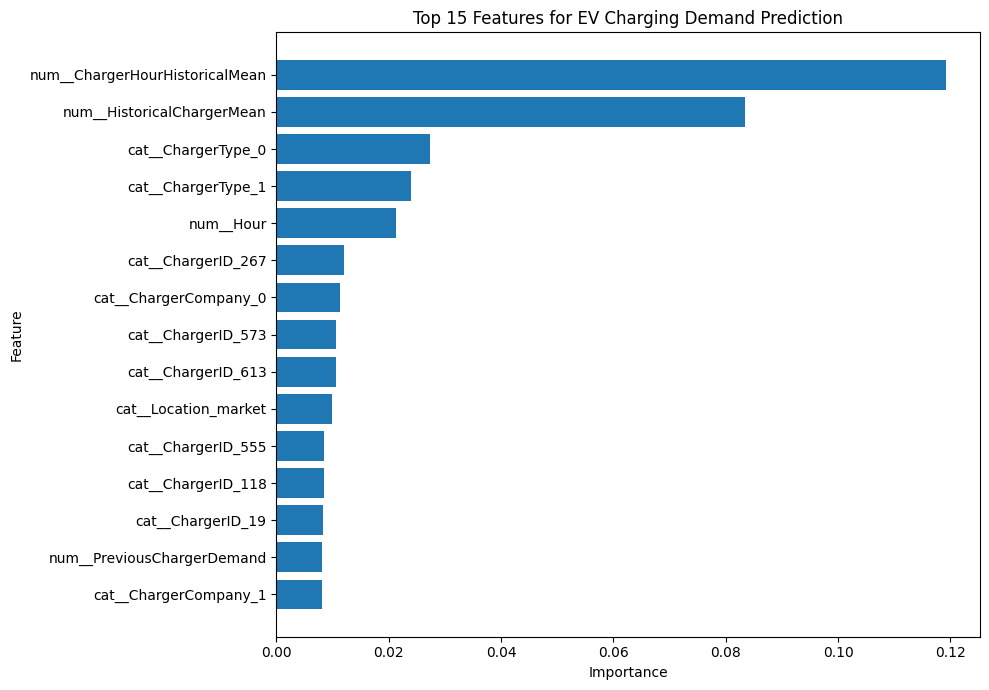

In [171]:
# Step 105 - Plot top feature importance

import matplotlib.pyplot as plt

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features for EV Charging Demand Prediction")

plt.tight_layout()
plt.show()

In [172]:
# Step 106 - Save feature importance

feature_importance_df.to_csv(
    "data/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


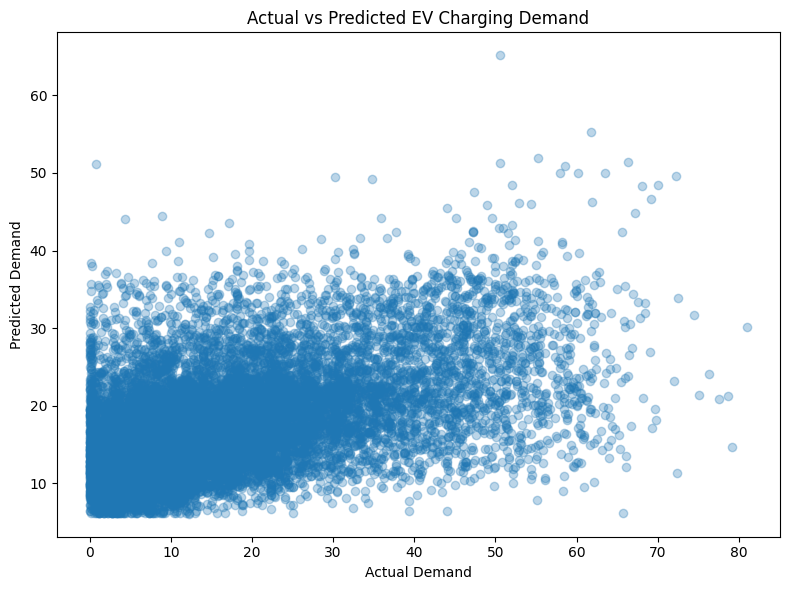

In [173]:
# Step 107 - Actual vs Predicted Demand

plt.figure(figsize=(8, 6))

plt.scatter(
    prediction_analysis["ActualDemand"],
    prediction_analysis["PredictedDemand"],
    alpha=0.3
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted EV Charging Demand")

plt.tight_layout()
plt.show()

In [174]:
# Step 108 - Residual analysis

prediction_analysis["Residual"] = (
    prediction_analysis["ActualDemand"]
    - prediction_analysis["PredictedDemand"]
)

prediction_analysis["Residual"].describe()

count    14572.000000
mean         0.110618
std         12.076003
min        -50.366584
25%         -7.413493
50%         -1.510097
75%          5.658536
max         64.382591
Name: Residual, dtype: float64

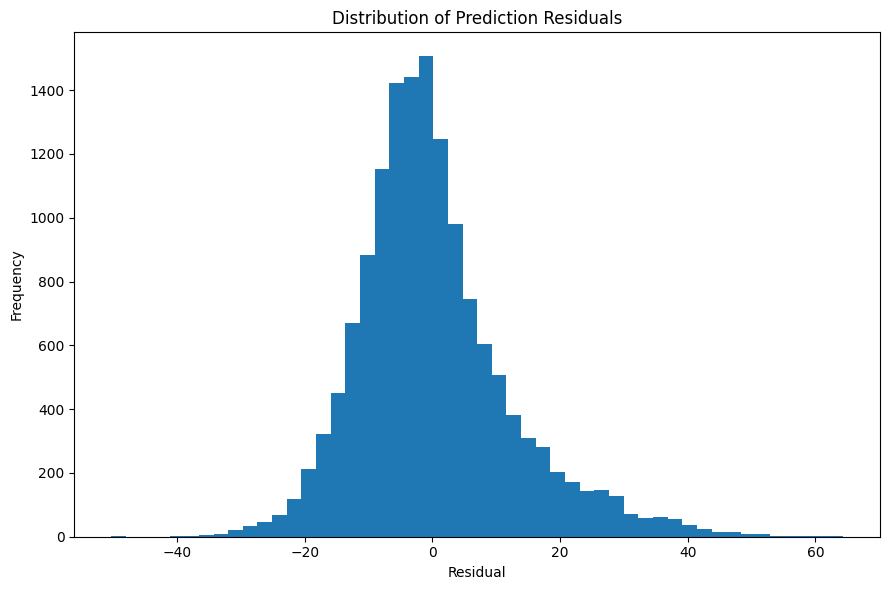

In [175]:
# Step 109 - Residual distribution

plt.figure(figsize=(9, 6))

plt.hist(
    prediction_analysis["Residual"],
    bins=50
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Residuals")

plt.tight_layout()
plt.show()

In [176]:
# Step 110 - Combine test data with predictions

test_analysis = test_data.copy().reset_index(drop=True)

test_analysis["PredictedDemand"] = final_predictions

test_analysis["PredictionError"] = (
    test_analysis["Demand"]
    - test_analysis["PredictedDemand"]
)

test_analysis["AbsoluteError"] = (
    test_analysis["PredictionError"].abs()
)

test_analysis.head()

,ChargerID,ChargerCompany,Location,ChargerType,Hour,DayOfWeek,DayOfMonth,WeekOfYear,Month,Year,...,PreviousChargerDemand,PreviousLocationDemand,HistoricalChargerMean,HistoricalLocationMean,ChargerHourHistoricalMean,StartDatetime,Demand,PredictedDemand,PredictionError,AbsoluteError
0,48,1,apartment,0,18,5,30,30,7,2022,...,9.40,22.60,20.990000,18.781431,29.450000,2022-07-30 18:39:00,18.20,24.557583,-6.357583,6.357583
1,42,1,hotel,0,18,5,30,30,7,2022,...,52.43,30.61,13.500681,14.703439,15.509091,2022-07-30 18:43:00,6.80,14.652075,-7.852075,7.852075
2,87,1,resort,0,18,5,30,30,7,2022,...,39.06,52.30,19.418972,16.946704,23.054167,2022-07-30 18:55:00,47.04,21.383938,25.656062,25.656062
3,628,0,public institution,0,18,5,30,30,7,2022,...,NaN,15.24,NaN,17.344816,NaN,2022-07-30 18:58:00,13.02,15.921079,-2.901079,2.901079
4,203,1,company,0,19,5,30,30,7,2022,...,45.12,20.76,21.218161,16.054338,19.417143,2022-07-30 19:03:00,3.53,21.677650,-18.147650,18.147650


In [177]:
# Step 111 - Average demand by hour

hourly_demand = (
    test_analysis
    .groupby("Hour")["Demand"]
    .agg(["count", "mean", "sum"])
    .reset_index()
)

hourly_demand

,Hour,count,mean,sum
0,0,165,26.249455,4331.16
1,1,92,23.945870,2203.02
2,2,35,27.837429,974.31
3,3,26,16.104231,418.71
4,4,38,16.607895,631.10
5,5,151,14.810662,2236.41
6,6,325,16.079200,5225.74
7,7,532,16.710432,8889.95
8,8,851,17.774653,15126.23
9,9,762,14.500814,11049.62


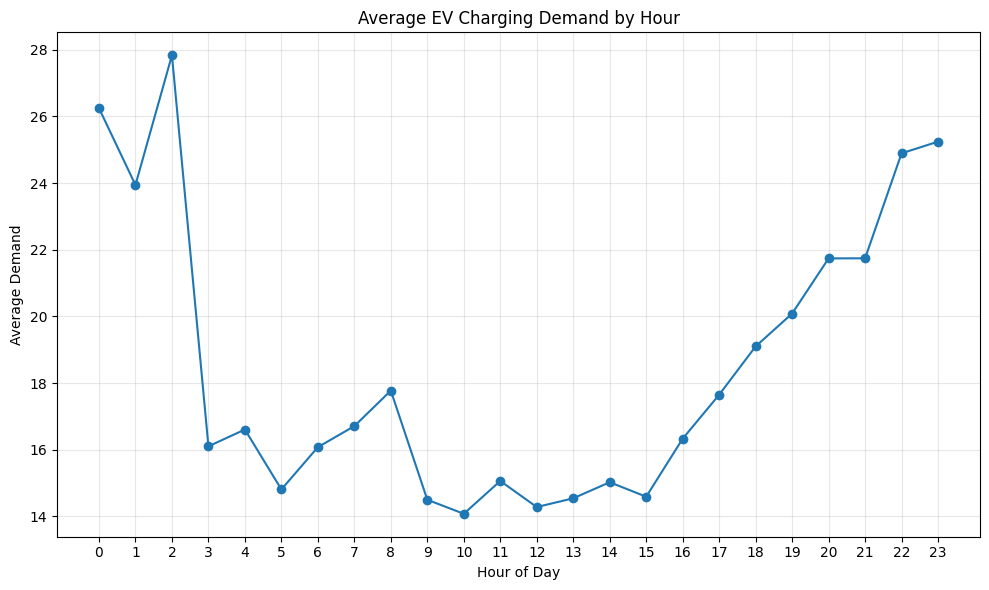

In [178]:
# Step 112 - Hourly demand pattern

plt.figure(figsize=(10, 6))

plt.plot(
    hourly_demand["Hour"],
    hourly_demand["mean"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Demand")
plt.title("Average EV Charging Demand by Hour")

plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [181]:
# Step 113 - Charger utilization summary

# Bring actual session duration back for utilization analysis only
test_analysis["Duration"] = df_clean.loc[
    test_data.index, "Duration"
].values

charger_utilization = (
    test_analysis
    .groupby("ChargerID")
    .agg(
        SessionCount=("ChargerID", "size"),
        TotalDuration=("Duration", "sum"),
        AverageDuration=("Duration", "mean"),
        TotalDemand=("Demand", "sum"),
        AverageDemand=("Demand", "mean")
    )
    .reset_index()
)

charger_utilization.head()

,ChargerID,SessionCount,TotalDuration,AverageDuration,TotalDemand,AverageDemand
0,1,89,14428,162.112360,1467.00,16.483146
1,2,54,9626,178.259259,1053.34,19.506296
2,3,76,10528,138.526316,982.98,12.933947
3,5,56,11830,211.250000,1095.00,19.553571
4,7,8,1018,127.250000,116.88,14.610000


In [182]:
# Step 114 - Most active chargers

charger_utilization_by_sessions = (
    charger_utilization
    .sort_values("SessionCount", ascending=False)
    .reset_index(drop=True)
)

charger_utilization_by_sessions.head(10)

,ChargerID,SessionCount,TotalDuration,AverageDuration,TotalDemand,AverageDemand
0,25,142,21377,150.542254,2271.18,15.994225
1,163,127,22338,175.889764,2361.17,18.591890
2,30,125,20982,167.856000,2040.97,16.327760
3,95,121,17503,144.652893,1901.33,15.713471
4,69,113,26201,231.867257,1696.19,15.010531
5,33,111,28395,255.810811,1665.40,15.003604
6,327,108,12280,113.703704,998.53,9.245648
7,42,107,14346,134.074766,1550.96,14.494953
8,66,107,16971,158.607477,1821.96,17.027664
9,29,99,16332,164.969697,1434.35,14.488384


In [183]:
print("Duration in df_clean:", "Duration" in df_clean.columns)
print("Rows in df_clean:", len(df_clean))
print("Rows in test_data:", len(test_data))
print("Rows in test_analysis:", len(test_analysis))

Duration in df_clean: True
Rows in df_clean: 72856
Rows in test_data: 14572
Rows in test_analysis: 14572


In [184]:
# Step 115 - Chargers with highest total demand

charger_utilization_by_demand = (
    charger_utilization
    .sort_values("TotalDemand", ascending=False)
    .reset_index(drop=True)
)

charger_utilization_by_demand.head(10)

,ChargerID,SessionCount,TotalDuration,AverageDuration,TotalDemand,AverageDemand
0,320,87,23196,266.620690,2463.63,28.317586
1,375,85,25435,299.235294,2422.54,28.500471
2,163,127,22338,175.889764,2361.17,18.591890
3,25,142,21377,150.542254,2271.18,15.994225
4,430,79,21064,266.632911,2251.67,28.502152
5,19,97,19885,205.000000,2223.77,22.925464
6,377,52,18811,361.750000,2165.84,41.650769
7,374,78,20135,258.141026,2050.23,26.285000
8,30,125,20982,167.856000,2040.97,16.327760
9,370,78,18751,240.397436,2018.83,25.882436


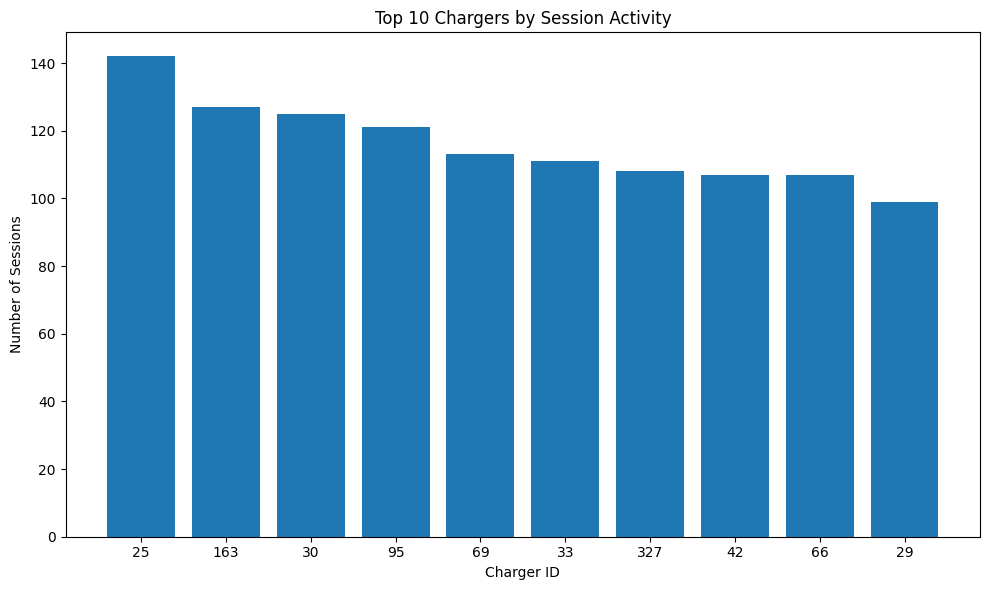

In [185]:
# Step 116 - Top chargers by session count

top_chargers = charger_utilization_by_sessions.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_chargers["ChargerID"].astype(str),
    top_chargers["SessionCount"]
)

plt.xlabel("Charger ID")
plt.ylabel("Number of Sessions")
plt.title("Top 10 Chargers by Session Activity")

plt.tight_layout()
plt.show()

In [186]:
# Step 117 - Location utilization summary

location_utilization = (
    test_analysis
    .groupby("Location")
    .agg(
        SessionCount=("Location", "size"),
        TotalDuration=("Duration", "sum"),
        AverageDuration=("Duration", "mean"),
        TotalDemand=("Demand", "sum"),
        AverageDemand=("Demand", "mean")
    )
    .reset_index()
)

location_utilization

,Location,SessionCount,TotalDuration,AverageDuration,TotalDemand,AverageDemand
0,accommodation,9,1930,214.444444,221.82,24.646667
1,apartment,2929,687261,234.640150,54520.54,18.614046
2,bus garage,6,182,30.333333,198.63,33.105000
3,camping,303,79069,260.953795,8435.22,27.839010
4,company,1175,189857,161.580426,20326.63,17.299260
5,golf,190,32931,173.321053,3072.48,16.170947
6,hotel,1668,242906,145.627098,24537.90,14.710971
7,market,557,44174,79.307002,9180.88,16.482729
8,public area,3041,380464,125.111476,53021.41,17.435518
9,public institution,1411,161091,114.167966,24856.30,17.616088


In [187]:
# Step 118 - Highest-demand locations

location_utilization_by_demand = (
    location_utilization
    .sort_values("TotalDemand", ascending=False)
    .reset_index(drop=True)
)

location_utilization_by_demand

,Location,SessionCount,TotalDuration,AverageDuration,TotalDemand,AverageDemand
0,apartment,2929,687261,234.640150,54520.54,18.614046
1,public area,3041,380464,125.111476,53021.41,17.435518
2,resort,1831,341131,186.308575,33987.84,18.562447
3,public institution,1411,161091,114.167966,24856.30,17.616088
4,hotel,1668,242906,145.627098,24537.90,14.710971
5,company,1175,189857,161.580426,20326.63,17.299260
6,public parking lot,667,32984,49.451274,12536.97,18.796057
7,market,557,44174,79.307002,9180.88,16.482729
8,restaurant,489,65223,133.380368,8984.75,18.373722
9,camping,303,79069,260.953795,8435.22,27.839010


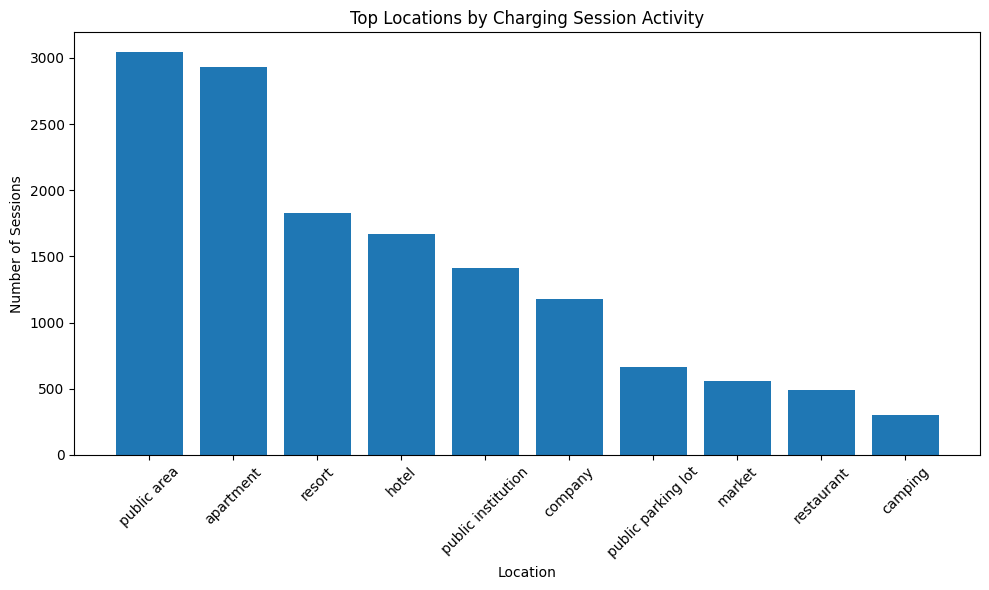

In [188]:
# Step 119 - Location session activity

location_plot_data = (
    location_utilization
    .sort_values("SessionCount", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.bar(
    location_plot_data["Location"],
    location_plot_data["SessionCount"]
)

plt.xlabel("Location")
plt.ylabel("Number of Sessions")
plt.title("Top Locations by Charging Session Activity")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [189]:
# Step 120 - Peak demand hours

peak_hours = (
    hourly_demand
    .sort_values("mean", ascending=False)
    .reset_index(drop=True)
)

peak_hours.head(10)

,Hour,count,mean,sum
0,2,35,27.837429,974.31
1,0,165,26.249455,4331.16
2,23,270,25.245593,6816.31
3,22,517,24.895532,12870.99
4,1,92,23.945870,2203.02
5,21,831,21.745499,18070.51
6,20,983,21.742309,21372.69
7,19,1116,20.087572,22417.73
8,18,1269,19.101899,24240.31
9,8,851,17.774653,15126.23


In [190]:
# Step 121 - Peak session activity hours

peak_session_hours = (
    hourly_demand
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

peak_session_hours.head(10)

,Hour,count,mean,sum
0,18,1269,19.101899,24240.31
1,17,1141,17.651709,20140.60
2,19,1116,20.087572,22417.73
3,16,999,16.332152,16315.82
4,20,983,21.742309,21372.69
5,8,851,17.774653,15126.23
6,21,831,21.745499,18070.51
7,15,826,14.592058,12053.04
8,13,801,14.544544,11650.18
9,14,775,15.026658,11645.66


In [191]:
# Step 122 - Save utilization analysis

charger_utilization.to_csv(
    "data/charger_utilization.csv",
    index=False
)

location_utilization.to_csv(
    "data/location_utilization.csv",
    index=False
)

hourly_demand.to_csv(
    "data/hourly_demand.csv",
    index=False
)

print("Utilization analysis files saved successfully.")

Utilization analysis files saved successfully.


In [192]:
# Step 123 - Operational summary

print("EV CHARGING DEMAND - OPERATIONAL SUMMARY")
print("=" * 50)

print("\nPeak demand hours:")
print(peak_hours.head(5)[["Hour", "mean", "count"]])

print("\nTop chargers by session activity:")
print(
    charger_utilization_by_sessions
    .head(5)[["ChargerID", "SessionCount", "TotalDemand", "AverageDemand"]]
)

print("\nTop locations by total demand:")
print(
    location_utilization_by_demand
    .head(5)[["Location", "SessionCount", "TotalDemand", "AverageDemand"]]
)

EV CHARGING DEMAND - OPERATIONAL SUMMARY

Peak demand hours:
   Hour       mean  count
0     2  27.837429     35
1     0  26.249455    165
2    23  25.245593    270
3    22  24.895532    517
4     1  23.945870     92

Top chargers by session activity:
   ChargerID  SessionCount  TotalDemand  AverageDemand
0         25           142      2271.18      15.994225
1        163           127      2361.17      18.591890
2         30           125      2040.97      16.327760
3         95           121      1901.33      15.713471
4         69           113      1696.19      15.010531

Top locations by total demand:
             Location  SessionCount  TotalDemand  AverageDemand
0           apartment          2929     54520.54      18.614046
1         public area          3041     53021.41      17.435518
2              resort          1831     33987.84      18.562447
3  public institution          1411     24856.30      17.616088
4               hotel          1668     24537.90      14.710971


In [193]:
# Step 124 - Save final ML pipeline

import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    final_model,
    "models/ev_demand_pipeline.joblib"
)

print("Final ML pipeline saved successfully.")

Final ML pipeline saved successfully.


In [194]:
# Step 125 - Verify saved pipeline

print(
    "Pipeline exists:",
    os.path.exists("models/ev_demand_pipeline.joblib")
)

print(
    "Pipeline size (MB):",
    round(
        os.path.getsize("models/ev_demand_pipeline.joblib") / (1024 * 1024),
        2
    )
)

Pipeline exists: True
Pipeline size (MB): 0.32


In [195]:
# Step 126 - Reload saved pipeline

loaded_model = joblib.load(
    "models/ev_demand_pipeline.joblib"
)

print("Saved pipeline loaded successfully.")

Saved pipeline loaded successfully.


In [196]:
# Step 127 - Test reloaded pipeline

loaded_predictions = loaded_model.predict(X_test)

print("Predictions generated:", len(loaded_predictions))
print("First 10 predictions:")
print(loaded_predictions[:10])

Predictions generated: 14572
First 10 predictions:
[24.557583 14.652075 21.383938 15.921079 21.67765  16.718842 27.06767
 11.566118 17.476511 17.858166]


In [197]:
# Step 128 - Verify prediction consistency

prediction_difference = np.max(
    np.abs(
        final_predictions - loaded_predictions
    )
)

print(
    "Maximum prediction difference:",
    prediction_difference
)

Maximum prediction difference: 0.0


In [198]:
# Step 129 - Evaluate reloaded pipeline

loaded_mae = mean_absolute_error(
    y_test,
    loaded_predictions
)

loaded_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        loaded_predictions
    )
)

loaded_r2 = r2_score(
    y_test,
    loaded_predictions
)

print("Reloaded Model Results")
print("----------------------")
print("MAE :", loaded_mae)
print("RMSE:", loaded_rmse)
print("R²  :", loaded_r2)

Reloaded Model Results
----------------------
MAE : 8.966741619098329
RMSE: 12.076095741327919
R²  : 0.2469087139159909


In [199]:
# Step 130 - Reusable prediction function

def predict_ev_demand(input_data):
    prediction = loaded_model.predict(input_data)
    return prediction[0]

In [200]:
# Step 131 - Test reusable prediction function

sample_input = X_test.iloc[[0]]

sample_prediction = predict_ev_demand(
    sample_input
)

print("Sample predicted demand:", sample_prediction)

Sample predicted demand: 24.557583


In [201]:
# Step 132 - Save final model information

final_model_info = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2",
        "Training Rows",
        "Testing Rows"
    ],
    "Value": [
        loaded_mae,
        loaded_rmse,
        loaded_r2,
        len(X_train),
        len(X_test)
    ]
})

final_model_info.to_csv(
    "data/final_model_info.csv",
    index=False
)

final_model_info

,Metric,Value
0,MAE,8.966742
1,RMSE,12.076096
2,R2,0.246909
3,Training Rows,58284.000000
4,Testing Rows,14572.000000


In [202]:
# Step 133 - Inspect final model input features

print("Number of model input features:", X_train.shape[1])
print("\nModel input columns:")
print(list(X_train.columns))

Number of model input features: 16

Model input columns:
['ChargerID', 'ChargerCompany', 'Location', 'ChargerType', 'Hour', 'DayOfWeek', 'DayOfMonth', 'WeekOfYear', 'Month', 'Year', 'IsWeekend', 'PreviousChargerDemand', 'PreviousLocationDemand', 'HistoricalChargerMean', 'HistoricalLocationMean', 'ChargerHourHistoricalMean']


In [203]:
# Step 134 - Inspect training data

print("Training rows:", len(train_data))
print("\nTraining columns:")
print(list(train_data.columns))

Training rows: 58284

Training columns:
['ChargerID', 'ChargerCompany', 'Location', 'ChargerType', 'Hour', 'DayOfWeek', 'DayOfMonth', 'WeekOfYear', 'Month', 'Year', 'IsWeekend', 'PreviousChargerDemand', 'PreviousLocationDemand', 'HistoricalChargerMean', 'HistoricalLocationMean', 'ChargerHourHistoricalMean', 'StartDatetime', 'Demand']


In [204]:
# Step 135 - Historical charger lookup

charger_history_lookup = (
    train_data
    .groupby("ChargerID")["Demand"]
    .mean()
    .reset_index()
    .rename(columns={
        "Demand": "HistoricalChargerMean"
    })
)

charger_history_lookup.head()

,ChargerID,HistoricalChargerMean
0,1,13.725619
1,2,10.538000
2,3,14.203319
3,5,24.073902
4,7,10.043182


In [205]:
# Step 136 - Historical location lookup

location_history_lookup = (
    train_data
    .groupby("Location")["Demand"]
    .mean()
    .reset_index()
    .rename(columns={
        "Demand": "HistoricalLocationMean"
    })
)

location_history_lookup.head()

,Location,HistoricalLocationMean
0,accommodation,29.278764
1,apartment,18.781431
2,bus garage,27.409130
3,camping,24.996986
4,company,16.054338


In [206]:
# Step 137 - Charger-hour historical lookup

charger_hour_lookup = (
    train_data
    .groupby(
        ["ChargerID", "Hour"]
    )["Demand"]
    .mean()
    .reset_index()
    .rename(columns={
        "Demand": "ChargerHourHistoricalMean"
    })
)

charger_hour_lookup.head()

,ChargerID,Hour,ChargerHourHistoricalMean
0,1,0,42.990000
1,1,6,7.466667
2,1,7,9.580000
3,1,8,9.378571
4,1,9,8.950714


In [207]:
# Step 138 - Location-hour historical lookup

location_hour_lookup = (
    train_data
    .groupby(
        ["Location", "Hour"]
    )["Demand"]
    .mean()
    .reset_index()
    .rename(columns={
        "Demand": "LocationHourHistoricalMean"
    })
)

location_hour_lookup.head()

,Location,Hour,LocationHourHistoricalMean
0,accommodation,0,32.796667
1,accommodation,1,17.830000
2,accommodation,2,6.590000
3,accommodation,5,6.060000
4,accommodation,6,22.290000


In [208]:
# Step 139 - Save prediction reference tables

charger_history_lookup.to_csv(
    "data/charger_history_lookup.csv",
    index=False
)

location_history_lookup.to_csv(
    "data/location_history_lookup.csv",
    index=False
)

charger_hour_lookup.to_csv(
    "data/charger_hour_lookup.csv",
    index=False
)

location_hour_lookup.to_csv(
    "data/location_hour_lookup.csv",
    index=False
)

print("Prediction reference tables saved successfully.")

Prediction reference tables saved successfully.


In [209]:
# Step 140 - Save model feature list

model_features = list(X_train.columns)

pd.DataFrame({
    "Feature": model_features
}).to_csv(
    "data/model_features.csv",
    index=False
)

print("Model feature list saved.")
print(model_features)

Model feature list saved.
['ChargerID', 'ChargerCompany', 'Location', 'ChargerType', 'Hour', 'DayOfWeek', 'DayOfMonth', 'WeekOfYear', 'Month', 'Year', 'IsWeekend', 'PreviousChargerDemand', 'PreviousLocationDemand', 'HistoricalChargerMean', 'HistoricalLocationMean', 'ChargerHourHistoricalMean']


In [210]:
# Step 141 - Verify final pipeline

print("Final model type:")
print(type(final_model))

print("\nPipeline steps:")
print(final_model.named_steps.keys())

Final model type:
<class 'sklearn.pipeline.Pipeline'>

Pipeline steps:
dict_keys(['preprocessor', 'model'])


In [211]:
# Step 142 - Verify deployment files

deployment_files = [
    "models/ev_demand_pipeline.joblib",
    "data/charger_history_lookup.csv",
    "data/location_history_lookup.csv",
    "data/charger_hour_lookup.csv",
    "data/location_hour_lookup.csv",
    "data/model_features.csv"
]

for file_path in deployment_files:
    print(
        file_path,
        "->",
        os.path.exists(file_path)
    )

models/ev_demand_pipeline.joblib -> True
data/charger_history_lookup.csv -> True
data/location_history_lookup.csv -> True
data/charger_hour_lookup.csv -> True
data/location_hour_lookup.csv -> True
data/model_features.csv -> True


In [212]:
# Step 143 - Final deployment checkpoint

print("=" * 60)
print("DEPLOYMENT CHECKPOINT")
print("=" * 60)

print("Final model saved        :", os.path.exists(
    "models/ev_demand_pipeline.joblib"
))

print("Model features saved     :", os.path.exists(
    "data/model_features.csv"
))

print("Charger lookup saved     :", os.path.exists(
    "data/charger_history_lookup.csv"
))

print("Location lookup saved    :", os.path.exists(
    "data/location_history_lookup.csv"
))

print("Charger-hour lookup saved:", os.path.exists(
    "data/charger_hour_lookup.csv"
))

print("\nModel input feature count:", len(model_features))

DEPLOYMENT CHECKPOINT
Final model saved        : True
Model features saved     : True
Charger lookup saved     : True
Location lookup saved    : True
Charger-hour lookup saved: True

Model input feature count: 16


In [213]:
# Step 144 - Create last known demand lookups

train_data_sorted = train_data.sort_values(
    "StartDatetime"
).copy()

last_charger_demand_lookup = (
    train_data_sorted
    .groupby("ChargerID")["Demand"]
    .last()
)

last_location_demand_lookup = (
    train_data_sorted
    .groupby("Location")["Demand"]
    .last()
)

overall_training_demand = train_data["Demand"].mean()

print("Charger lookup entries:",
      len(last_charger_demand_lookup))

print("Location lookup entries:",
      len(last_location_demand_lookup))

print("Overall training demand:",
      overall_training_demand)

Charger lookup entries: 1964
Location lookup entries: 14
Overall training demand: 17.3695799876467


In [214]:
# Step 145 - Create prediction function

def create_prediction_input(
    charger_id,
    charger_company,
    location,
    charger_type,
    start_datetime
):
    
    start_datetime = pd.to_datetime(start_datetime)

    hour = start_datetime.hour
    day_of_week = start_datetime.dayofweek
    day_of_month = start_datetime.day
    week_of_year = int(start_datetime.isocalendar().week)
    month = start_datetime.month
    year = start_datetime.year
    is_weekend = day_of_week >= 5

    previous_charger_demand = last_charger_demand_lookup.get(
        charger_id,
        overall_training_demand
    )

    previous_location_demand = last_location_demand_lookup.get(
        location,
        overall_training_demand
    )

    historical_charger_mean = charger_history_lookup.loc[
        charger_history_lookup["ChargerID"] == charger_id,
        "HistoricalChargerMean"
    ]

    if len(historical_charger_mean) > 0:
        historical_charger_mean = historical_charger_mean.iloc[0]
    else:
        historical_charger_mean = overall_training_demand

    historical_location_mean = location_history_lookup.loc[
        location_history_lookup["Location"] == location,
        "HistoricalLocationMean"
    ]

    if len(historical_location_mean) > 0:
        historical_location_mean = historical_location_mean.iloc[0]
    else:
        historical_location_mean = overall_training_demand

    charger_hour_mean = charger_hour_lookup[
        (charger_hour_lookup["ChargerID"] == charger_id) &
        (charger_hour_lookup["Hour"] == hour)
    ]["ChargerHourHistoricalMean"]

    if len(charger_hour_mean) > 0:
        charger_hour_mean = charger_hour_mean.iloc[0]
    else:
        charger_hour_mean = historical_charger_mean

    prediction_input = pd.DataFrame({
        "ChargerID": [charger_id],
        "ChargerCompany": [charger_company],
        "Location": [location],
        "ChargerType": [charger_type],
        "Hour": [hour],
        "DayOfWeek": [day_of_week],
        "DayOfMonth": [day_of_month],
        "WeekOfYear": [week_of_year],
        "Month": [month],
        "Year": [year],
        "IsWeekend": [is_weekend],
        "PreviousChargerDemand": [previous_charger_demand],
        "PreviousLocationDemand": [previous_location_demand],
        "HistoricalChargerMean": [historical_charger_mean],
        "HistoricalLocationMean": [historical_location_mean],
        "ChargerHourHistoricalMean": [charger_hour_mean]
    })

    return prediction_input

In [215]:
# Step 146 - Test prediction input creation

sample_row = test_data.iloc[0]

sample_input = create_prediction_input(
    charger_id=sample_row["ChargerID"],
    charger_company=sample_row["ChargerCompany"],
    location=sample_row["Location"],
    charger_type=sample_row["ChargerType"],
    start_datetime=sample_row["StartDatetime"]
)

sample_input

,ChargerID,ChargerCompany,Location,ChargerType,Hour,DayOfWeek,DayOfMonth,WeekOfYear,Month,Year,IsWeekend,PreviousChargerDemand,PreviousLocationDemand,HistoricalChargerMean,HistoricalLocationMean,ChargerHourHistoricalMean
0,48,1,apartment,0,18,5,30,30,7,2022,True,9.4,22.6,20.99,18.781431,29.45


In [216]:
# Step 147 - Verify prediction feature structure

print("Input shape:", sample_input.shape)

print("\nInput columns:")
print(list(sample_input.columns))

print("\nModel columns:")
print(list(X_train.columns))

print(
    "\nColumns match:",
    list(sample_input.columns) == list(X_train.columns)
)

Input shape: (1, 16)

Input columns:
['ChargerID', 'ChargerCompany', 'Location', 'ChargerType', 'Hour', 'DayOfWeek', 'DayOfMonth', 'WeekOfYear', 'Month', 'Year', 'IsWeekend', 'PreviousChargerDemand', 'PreviousLocationDemand', 'HistoricalChargerMean', 'HistoricalLocationMean', 'ChargerHourHistoricalMean']

Model columns:
['ChargerID', 'ChargerCompany', 'Location', 'ChargerType', 'Hour', 'DayOfWeek', 'DayOfMonth', 'WeekOfYear', 'Month', 'Year', 'IsWeekend', 'PreviousChargerDemand', 'PreviousLocationDemand', 'HistoricalChargerMean', 'HistoricalLocationMean', 'ChargerHourHistoricalMean']

Columns match: True


In [217]:
# Step 148 - Generate sample prediction

sample_prediction = loaded_model.predict(
    sample_input
)

print("Predicted EV charging demand:",
      sample_prediction[0])

Predicted EV charging demand: 24.557583


In [218]:
# Step 149 - Compare prediction with actual demand

actual_demand = sample_row["Demand"]
predicted_demand = sample_prediction[0]

print("Actual demand    :", actual_demand)
print("Predicted demand :", predicted_demand)
print("Absolute error   :", abs(
    actual_demand - predicted_demand
))

Actual demand    : 18.2
Predicted demand : 24.557583
Absolute error   : 6.35758285522461


In [219]:
# Step 150 - Future-style prediction example

future_input = create_prediction_input(
    charger_id=25,
    charger_company="Company_A",
    location="hotel",
    charger_type=0,
    start_datetime="2022-10-05 20:00:00"
)

future_input

,ChargerID,ChargerCompany,Location,ChargerType,Hour,DayOfWeek,DayOfMonth,WeekOfYear,Month,Year,IsWeekend,PreviousChargerDemand,PreviousLocationDemand,HistoricalChargerMean,HistoricalLocationMean,ChargerHourHistoricalMean
0,25,Company_A,hotel,0,20,2,5,40,10,2022,False,11.56,30.61,13.979283,14.703439,25.288611


In [220]:
# Step 151 - Predict future-style demand

future_prediction = loaded_model.predict(
    future_input
)

print(
    "Predicted charging demand:",
    future_prediction[0]
)

Predicted charging demand: 20.293983


In [222]:
# Step 152 - Verify application assets

application_assets = [
    "models/ev_demand_pipeline.joblib",
    "data/charger_history_lookup.csv",
    "data/location_history_lookup.csv",
    "data/charger_hour_lookup.csv",
    "data/location_hour_lookup.csv"
]

for asset in application_assets:
    print(asset, "->", os.path.exists(asset))

models/ev_demand_pipeline.joblib -> True
data/charger_history_lookup.csv -> True
data/location_history_lookup.csv -> True
data/charger_hour_lookup.csv -> True
data/location_hour_lookup.csv -> True


In [223]:
# Step 153 - Verify application folder

os.makedirs("app", exist_ok=True)

print("Application folder ready.")

Application folder ready.


In [224]:
# Step 154 - Save previous demand lookup tables

last_charger_demand_lookup.to_csv(
    "data/last_charger_demand_lookup.csv",
    header=["PreviousChargerDemand"]
)

last_location_demand_lookup.to_csv(
    "data/last_location_demand_lookup.csv",
    header=["PreviousLocationDemand"]
)

print("Previous-demand lookup tables saved.")

Previous-demand lookup tables saved.


In [225]:
# Step 155 - Save application options

app_options = df_clean[
    [
        "ChargerID",
        "ChargerCompany",
        "Location",
        "ChargerType"
    ]
].drop_duplicates()

app_options.to_csv(
    "data/app_options.csv",
    index=False
)

print("Application options saved.")
print("Rows:", len(app_options))

Application options saved.
Rows: 2119


In [226]:
# Step 156 - Verify application files

application_files = [
    "models/ev_demand_pipeline.joblib",
    "data/app_options.csv",
    "data/charger_history_lookup.csv",
    "data/location_history_lookup.csv",
    "data/charger_hour_lookup.csv",
    "data/last_charger_demand_lookup.csv",
    "data/last_location_demand_lookup.csv"
]

for file_path in application_files:
    print(file_path, "->", os.path.exists(file_path))

models/ev_demand_pipeline.joblib -> True
data/app_options.csv -> True
data/charger_history_lookup.csv -> True
data/location_history_lookup.csv -> True
data/charger_hour_lookup.csv -> True
data/last_charger_demand_lookup.csv -> True
data/last_location_demand_lookup.csv -> True
